# Domača Naloga 3

## Naloga 1: Nenadzorovano učenje in predprocesiranje podatkov

### 1.a: Identifikacija povezovalnega kriterija

Spodaj so trije dendrogrami, narejeni na isti podatkovni množici, vsak z drugo funkcijo združevanja (linkage): enojno (single), celovito (complete) in Wardovo. Določi, kateri dendrogram je bil pridobljen s katero funkcijo. Vsako izbiro funkcije utemelji z vsaj eno konkretno značilnostjo dendrograma (ne zgolj z imenom funkcije ali dendrograma).

![dendrogrami](1a_dendrogrami.png)

**Vprašanji:** 
- Če bi dendrogram C odrezal/a tako, da bi dobil/a natanko tri (3) skupine, ali bi bile velikosti dobljenih skupin bolj ali manj uravnotežene kot pri istem prerezu dendrograma A?  
**Odgovor**: Velikost dobljenih skupin bi bila bolj uranotežena pri C kot pri A. Ko na isti višini odrežemo A, dobimo dve skupini, leva ima malo opazovanj desna pa veliko. Pri treh skupinah dedrograma C pa je število opazovanj v vsaki skupini približno enako.
- Pojasni, zakaj Wardov kriterij teži k (po velikosti) bolj uravnoteženim skupinam.  
**Odgovor**: kriterij temelji na minimizaciji varinace znotraj skupin. Da bi ohranil nizko varianco, algoritem raje združuje skupine, ki imata podobno število točk in sta si blizu. Posledično se oblikujejo podobno velike in uravnotežene skupine. Dendrogram, zato tudi izgleda približno simetričen.

**Pari, pojasnila in odgovora:**
- Dendrogram A: **SINGLE**. Dendrogram je zelo nesimetričen in v primerjavi z ostalima dendrogramam se zadnja združitev zgodi malo nad 5 (kar niže od ostalih dveh). To ni nenavadno za single, saj povezuje glede na najbližje točke v skupini.
- Dendrogram B: **COMPLETE**. Združitve se zgodijo pri višinah, ki se zmerno razlikujejo med seboj. Ima tudi kar simetrično strukturo, značilno za complete linkage. Vrh je tudi manj izrazit kot pri C.
- Dendrogram C: **WARD**. Funkcija minimizira varianco znotrja skupin, zato so začetna združevanja, zelo nizko in izgledajo kompaktne. Značilen je tudi veliki skok pri vrhu.

### 1.b: Izbira števila skupin — komolec proti silhueti

Spodaj so prikazani podatki (levo), pripadajoči komolčni diagram (inercija $K$-Means glede na število skupin $K$) in graf vrednosti silhuet glede na $K$:

![izbira K](1b_k_izbira.png)

Heuristiki za izbiro števila skupin kažeta v različno smer: komolec sugerira eno vrednost $K$, silhueta drugo.

**Vprašanja:**

- Iz vsakega diagrama (komolec in silhuete) odčitaj priporočeno vrednost $K$. Pojasni, zakaj se vrednosti razhajata: kaj v strukturi teh podatkov povzroči razkorak?
- Pojasni, kdaj lahko silhueta za posamezen primer postane negativna. Kaj to konkretno pove o tistem primeru in celotnem razvrščanju v skupine.
- Katero vrednost $K$ bi sam/a izbral/a, če bi videl/a samo komolčni in samo silhuetni diagram (brez scatter plota diagrama podatkov)? Kaj bi naredil/a, če bi imel/a tudi scatter plot, pa bi vseeno hotel/a podpreti kvantitativno odločitev? (Namig: premisli o hierarhični strukturi, ki je prisotna pri razvrščanju teh podatkov.)

**Odgovori:**
- Za diagram komolca je K = 6 (tam kje je "komolec"), za diagram silhuete pa je priporočena vrednsot K = 2. Do razkoraka pride, zaradi strukture podatkov. Na prvi sliki vidimo, da so podatki v grobem razdeljeni v dve skupini (zgoraj desno in spodaj levo). Ampak vsaka od teh dveh skupin ima tri podskupine. Torej na finem nivoju so podatki dejansko razporejeni v 6 skupin. Silhueta za vsak primer meri kako dobro je  umeščen v skupino v primerjvi s najbližjo sosednjo skupino. Digram silhuete zato priporoča K = 2, ker je razdlaja med zg desno skupino in sp levo zelo velika v primejavi z razdlajo znotrja teh skupin. Inercija (diagram komoleca) pa meri kompaktnost skupine. Zato priporča K = 6 in ne K = 2, saj skupni pri K = 2 nebi bili zelo kompaktni (saj bi vsaka v v bistvu imal 3 podskupine).
- Negativna silhueta (med -1 in 0) za posamezen primer pomeni, da je ta primer verjetno bil dan v napačno skupino. To ni nenavadno za posamezne točke na meji med dvema skupinama. Če pa si zamislimo primer, da bi bilo povprečje silhout negativno (vrednost silhoute bi na zgornjem grafu padlo pod nič) pa lahko pomeni, da je število skupin pre veliko in se lahko prekrivajo.
- Če bi imel samo komolčni diagram bi izbral K = 6, pri silhueti bi se odločil za K = 2, če pa bi imel oba diagrama in scatter plot pa bi izbral K = 6. Glede na scatter plot je jasno, da je v glavnem 6 skupin. To podpira diagram komolca, silhueta pa ima tudi zelo visoko vrednost pri K = 6 (vrednost je blizu tiste za K = 2)




### 1.c: Lokalni minimumi pri K-Means

Spodaj so prikazana štiri gručenja s K-Means na isti podatkovni množici. Razlika med gručenji je nastala zgolj zaradi različnih postavitev začetnih centroidov (`init='random'`, `n_init=1`, različne nastavitve `random_state`, t.j., semena za generator naključnih števil). Naslov vsake slike vsebuje tudi inercijo (vsoto kvadratov razdalj do centroidov) za ustrezno gručenje.

![lokalni minimumi](1c_lokalne.png)

**Vprašanja:**

- Zgornja gručenja se razlikujejo. Pojasni razlike in dejstvo, da se tudi končne inercije, kljub konvergenci algoritma, medsebojno razlikujejo. Katero od štirih gručenj je glede na inercijo najboljše? Zakaj to ne pomeni, da je nujno tudi to razvrščanje prava izbira za to podatkovno množico?
- V praksi `KMeans` v `sklearn` uporablja privzete nastavitve `n_init=10` in `init='k-means++'`. Razišči in pojasni, kaj _K-Means++_ počne. Zakaj v večini primerov bistveno zmanjša verjetnost slabega končnega razvrščanja?
- Konstruiraj (ali besedno opiši) majhno podatkovno množico, kjer tudi K-Means++ z visokim `n_init` še vedno (v večini primerov) ne najde prave rešitve. Kakšna struktura podatkov to povzroči? (Namig: o teh primerih smo govorili tudi na vajah.)
- Predlagaj dve rešitvi, ki bi pravilno gručila podatke na zgornji sliki.

**Odgovori:**
- Razlike med gručanjem 2, 3 in 4 so minimalne. Te skupine imajo identične inercije (zamenjana barva gruč zgoraj levo v 4 v primejavi s 2 in 3 ni pomebna). Gručenje 1 se jasno razlikuje od ostalih (ima tudi bistveno slabšo inercijo). Algoritem bo vedno konvergiral, ampak pri 2, 3, 4 so vsi konvergirali k podobnem lokalnem minimumu, pri 1 pa so začetni centroidi verjetno pristali na neugodnih mestah in je zato algoritem konvergiral k drugemu lokalnemu minimumu. V splošnem pa se inercije razlikujejo, ker alogritem konvergira k nekemu lokalnemu min ne globalnemu in zato začetna postavitev centroidov lahko zelo spremeni končne gruče.  
Glede na inercijo je najbolše gručenje 2. Ker pa inercija meri samo kompaktnost gruče ni nujno da odraža strukturo podatkov. K-means deluje najboljše na okroglih gručah, v tem primeru pa so podatki razporejeni nekako v tri oblake, s tem pa ima lahko algoritem težave. Tako razvrščanje, zato ni nujno pravo za to množico.
- K-means++ začetne centroide gruč izbere z vzorčenjem na podlagi empirične porazdelitve verjetnosti, ki temelji na prispevku vsake točke k skupni inerciji. Ta tehnika pospeši konvergenco. Algoritem v vsakem koraku vzorčenja opravi več poskusov in med njimi izbere najboljši centroid.  
To zmanjša verjetnost slabega končnega razvrščanja, ker razprši začetne centroide in se težje zgodi situacija kot pri gručenju 1, da ima ena naravna gruča dva centroida.
- [Slika podatkovne mn, kje K-Menas++ nebi našla dobre rešitve](https://media.datacamp.com/cms/google/ad_4nxch8tpv0melxtojqte2mosdtbflwni1crdpx79eexsmli13kncneuxapbrtjtafqs2jht6tojwfmbd6gy9rxwt_faiwmr3inkhptxdoanrinti83bvo7bp2bqbf6dc86mcbr6m5y9rjfukxeivlau1h8we.jpeg). 
Podatki, ki povzorčijo slabo gručenje so tisti, ki niso okrogli. Že v našem primeru vidimo, da algoritmu delajo problem taka podlgovate skupine.
- Rešitvi, ki bi ju jaz priporčal je, da namesto K-Means uporabimo DBSCAN (kot smo pri dodatni nalogi, vaje 9) ali pa spekralno gručenje (Spectral Clustering).

### 1.d: Prekletstvo večrazsežnosti

Spodaj so prikazane porazdelitve evklidskih razdalj med vsemi pari $n = 300$ naključno (enakomerno) vzorčenih točk v $[0,1]^d$ za tri različne dimenzionalnosti prostora $d \in \{2,\ 20,\ 500\}$:

![curse of dim](1d_kletev.png)

V naslovih slik sta navedena povprečje in standardni odklon razdalj ter njuno razmerje $\text{std} / \text{povp}$.

**Vprašanja:**

- Z rastjo razsežnosti prostora, vrednost razmerje $\text{std}/\text{povp}$ strmo pada (s $\sim 0.48$ pri $d=2$ na $\sim 0.03$ pri $d=500$). Pojasni intuitivno, zakaj se to zgodi.
- Kako ta pojav vpliva na algoritmih K-Means, DBSCAN in klasifikacijo s KNN v zelo visokorazsežnostnih prostorih? Za vsakega od treh algoritmov identificiraj konkretno komponento, ki v teh prostorih postane praktično neuporabna in pojasni zakaj je temu tako.
- Pogosta strategija pred razvrščanjem visokorazsežnostnih podatkov je uporaba algoritmov za krčenje razsežnosti kot je PCA (npr. iz 500D v 10D), nato pa razvrščanje v skupine v skrčenem (nizkorazsežnostnem) podatkovnem prostoru. Pojasni kdaj taka strategija pomaga (kakšne so značilnosti podatkov, kjer PCA odkrije pravo strukturo) in kdaj škoduje (kjer PCA struktur, pomembnih za razvrščanje v skupine, ne najde).

**Odgovori:**
- Vrednost razmerja pada, zaradi tega, ker z višanjem dimenzije posataja razdalja med točkami 
večje (seveda s tem se tudi poveča povprečna razdalja), std pa stoja dokaj konstantna.
- Na zgoraj omenjene model, večanje dimenzije (prekletsto razsežnosti) zelo poslabša njihovo delovanje. V visokih dimenzija Euklidska razdlaja izgubi svojo pomen, saj razdlje med točkami postanejo skoraj enake.  
Pri K-Menas postane neuporabna komponenta n_clusters. Ker so si točke v visokih dimenzijah približno enako oddaljenen, ni več nekih jasnih gruč kot so ponavadi v nižjih dimenzijah, zato št gruč postane nepomebno.
Pri DBSACN postane neuporabna komponenta eps (ϵ). Če je premajhen potem za neko točko ne nejde nobenega soseda, ampak ko pa ga povečamo pa kar naekrat razglasi vse točke za sosednje in tako dobimo eno gručo, ki je seveda neuporabna. 
Pri KNN postane neuporabna komponenta k (št najbližjih sosedov), saj za neko točko sta njeni 1. najbližji sosed in k-ti najbližji sosed praktično enako oddaljena.
- PCA je smiselen, ko je prava struktura podatkov linerna in ko večina informacij o njihovi strukturi lahko povzamemo s prvimi nekaj komponentami. Škodi, torej ko je struktura podatkov nelinearna (npr. če imamo obročaste gruče).

## Naloga 2: Izbira napovednih spremenljivk z algoritmom ReliefF

V tej nalogi boš implementiral/a algoritem ReliefF, ki oceni pomembnost (napovedno moč) napovednih spremenljivk z analizo najbližjih sosedov: tistih z isto vrednostjo ciljne spremenljivke (*nearest hits*) in tistih z različno vrednostjo ciljne spremenljivke (*nearest misses*). Logična predpostavka algoritma je, da dobra napovedna spremenljivka ima podobne vrednosti v primerih z isto vrednostjo ciljne spremenljivke in zelo različne vrednosti v primerih z različno vrednostjo ciljne spremenljivke.

ReliefF je razširitev osnovnega algoritma Relief za večrazredne probleme (probleme kjer je domena $D_Y$ ciljne spremenljivke $Y$ taka, da velja $|D_Y| > 2$) in z večjo odpornost na šum. ReliefF namesto enega najbližjega upošteva $k$ najbližjih sosedov, pri *nearest misses* pa povpreči preko vseh vrednostih ciljne spremenljivke, ki se razlikujejo od vrednosti ciljne spremenljivke opazovanega primera, z utežmi glede na porazdelitev vrednosti ciljne spremenljivke v učni množici.

### 2.a: Razdalja po spremenljivkah

Preden lahko iščemo najbližje sosede, moramo definirati, kako merimo razdaljo med dvema primeroma po posamezni spremenljivki. ReliefF razdaljo definira različno glede na tip spremenljivke:

- numerična: $\text{diff}(f, x_1, x_2) = \dfrac{|x_1^{(f)} - x_2^{(f)}|}{\max(f) - \min(f)}$
- kategorična: $\text{diff}(f, x_1, x_2) = \begin{cases} 0 & \text{če } x_1^{(f)} = x_2^{(f)} \\ 1 & \text{sicer} \end{cases}$,

kjer $f$ je oznaka spremenljivke, $\max{f}$ in $\min{f}$ sta maksimalna in minimalna vrednost te spremenljivke, $x_1$ in $x_2$ sta primera, ter $x^{(f)}$ je vrednost spremenljivke $f$ v primeru $x$.

Dopolni funkcijo `diff`, ki za podana primera vrne vektor njunih razdalj po vseh spremenljivkah. Skupno razdaljo med primeroma bomo kasneje računali kot vsoto (ali $\ell_1$ normo) tega vektorja.

**Vprašanje:** Zakaj numerične spremenljivke normaliziramo?

**Odgovor:** Različne numerične spremenljivke imajo lahko različne razpone (npr. starost bi bila med 18-90 let, višina med 150-200cm...),
zato je nujno, da jih normaliziramo in s tem zagotovimo, da vse spremenljivke enako prispevajo k razdalji.

In [35]:
import numpy as np

def diff(x1, x2, feature_ranges, categorical_mask):
    """
    Izračuna razdaljo med primeroma x1 in x2 po vsaki spremenljivki posebej.
    """
    # Dopolni
    distance = np.where(categorical_mask, (x1 != x2).astype(float), np.abs(x1 - x2) / feature_ranges)
    return distance


# Test
x1 = np.array([0.0, 1.0, 0.0])
x2 = np.array([1.0, 0.0, 1.0])
x3 = np.array([0.5, 1.0, 0.0])
ranges = np.array([1.0, 1.0, 1.0])
cat_mask = np.array([False, True, True])

print(diff(x1, x2, ranges, cat_mask))  # pričakovano: [1.0, 1.0, 1.0]
print(diff(x1, x3, ranges, cat_mask))  # pričakovano: [0.5, 0.0, 0.0]

[1. 1. 1.]
[0.5 0.  0. ]


### 2.b: ReliefF — najbližji zadetki in zgrešitve

Za vsak naključno izbran primer $R$ s ciljno vrednostjo (vrednostjo ciljne spremenljivke) $y(R)$ poiščemo njegove najbližje sosede:
- najbližje zadetke (*nearest hits*) — $k$ najbližjih primerov z isto ciljno vrednostjo kot $R$,
- najbližje zgrešitve (*nearest misses*) — $k$ najbližjih primerov iz vsake druge vrednosti ciljne spremenljivke, ki ni enaka ciljni vrednosti primera $R$.

Ideja posodobitve uteži je naslednja: če ima spremenljivka pri zadetkih majhno razdaljo (kar je dobro!) in pri zgrešitvah veliko razdaljo (tudi dobro!), se njena utež poveča. Pri zgrešitvah iz različnih razredov računamo obteženo povprečje z utežmi glede na apriorne verjetnosti ciljne spremenljivke $P(C)$, ker želimo redke in pogoste razrede obravnavati sorazmerno. Posodobitev uteži definira naslednji predpis:

$$w_f \leftarrow w_f - \frac{1}{m \cdot k}\sum_{j=1}^{k}\text{diff}(f, R, H_j) + \frac{1}{m \cdot k}\sum_{C \neq y(R)}\frac{P(C)}{1 - P(y(R))}\sum_{j=1}^{k}\text{diff}(f, R, M_j(C))$$

kjer so $H_j$ za $j = 1, 2, \dots, k$, najbližji zadetki, $M_j(C)$ za $j = 1, 2, \ldots, k$ najbližje zgrešitve iz razreda $C$ in $m$ število iteracij, ki je enako številu izbranih primerov $R$. Skupno razdaljo med dvema primeroma (za iskanje najbližjih sosedov) izračunaj kot vsoto vektorja `diff` po vseh spremenljivkah.

Dopolni funkcijo `relieff` tako, da bo implementirala zgoraj opisan pristop.

**Vprašanji:**

- Zakaj povprečenje preko $k$ sosedov poveča robustnost na šum v oznakah? Zakaj zgrešitve iz različnih razredov utežimo z njihovimi apriornimi verjetnostmi in kaj bi se zgodilo, če bi vse razrede obravnavali enako, ne glede na to, koliko primerov pripada vsakemu?
- ReliefF je razširitev osnovnega Relief algoritma. Pod kakšnimi pogoji in konfiguracijo bo ReliefF deloval enako kot Relief — brez kakršnih koli sprememb kode?

**Odgovora:**
- Povprečenje preko k sosedov poveča robustnost, zato ker ocena pomebnosti ni več odvisna od enega samega primera (ki bi lahko npr bil napačno označen), ampak na več najbližjih primerov. Vpliv posameznih primerov je torej omejen.  
Zgrešitve različnih razredov utežimo z apriornimi verjetnostmi, ker s tem poskrbimo, da vsak razred prispeva k posodobitvi uteži sorazmerno s svojo pogostostjo. Če bi vse razrede obravnavali enako bi redki razredi imeli nesorazmerno velik vpliv glede na svojo velikost. Spremenljivke, ki dobro ločijo redke razrede bi postale precenjene, spremenljivke, ki pa dobro ločijo pogoste razrede bi pa bile podcenjene.
- ReliefF bi deloval kot Relief, če bi nastavili k = 1 (samo en najbližji sosed) in v ciljni spremenljivki bi bila samo 2 razreda.


In [36]:
def relieff(X, y, n_iterations, k, feature_ranges, categorical_mask, rng=None):
    """
    ReliefF algoritem za večrazredno klasifikacijo.
    """
    # Dopolni

    #Ti vrstici poskrbita, da tudi če ne nastavimo generator naključ št,
    #bo funkcija še vedno delovala. 
    if rng is None:
        rng = np.random.default_rng() 
    
    n_samples, n_features = X.shape
    #Uteži bodo na začetku enake 0
    weights = np.zeros(n_features)
    classes = np.unique(y)
    #Apriorne verjetnosti
    class_probs = {c: np.mean(y == c) for c in classes}
    #Indeksi primerov glede na razrede
    class_indices = {c: np.where(y == c)[0] for c in classes}
    #V tej vrstici se naključno izbere n_iterations (m) primerov R
    sample_indices = rng.choice(n_samples, size=n_iterations, replace=False)
    
    for i in sample_indices:
        R = X[i]
        y_R = y[i]
        #Izrač razdalje od R do ostalih primrov
        distances = np.array([np.sum(diff(R, X[j], feature_ranges, categorical_mask)) for j in range(n_samples)])
        #R ne sme iti sam svoj sodsed, zato to izključimo
        distances[i] = np.inf  

        #Nearest hits
        hit_indices = class_indices[y_R]
        hit_distances = distances[hit_indices]
        nearest_hits = hit_indices[np.argsort(hit_distances)[:k]]
        #Posodobimo uteži (odštejemo nearest hits)
        for h in nearest_hits:
            weights -= diff(R, X[h], feature_ranges, categorical_mask) / (n_iterations * k)
    
        #Nearest misses
        for c in classes:
            if c == y_R:
                continue
            miss_indices = class_indices[c]
            miss_distances = distances[miss_indices]
            nearest_misses = miss_indices[np.argsort(miss_distances)[:k]]
            #Utež razreda
            p_c = class_probs[c]
            p_y_R = class_probs[y_R]
            class_weight = p_c / (1 - p_y_R)
            #Posodobimo uteži (nearest misses prištejemo)
            for m in nearest_misses:
                weights += class_weight * diff(R, X[m], feature_ranges, categorical_mask) / (n_iterations * k)
    
    return weights
    

# Test na večrazrednem primeru
rng = np.random.default_rng(42)
n = 300
X_test = rng.normal(0, 1, (n, 4))
y_test = rng.integers(0, 3, n)
X_test[:, 0] += 2 * y_test  # samo prva spremenljivka loči razrede

ranges = X_test.max(axis=0) - X_test.min(axis=0)
cat_mask = np.array([False, False, False, False])

weights = relieff(X_test, y_test, n_iterations=300, k=10,
                  feature_ranges=ranges, categorical_mask=cat_mask,
                  rng=np.random.default_rng(0))
print("Uteži:", weights)
print("Najpomembnejša spremenljivka:", np.argmax(weights), "(pričakovano: 0)")

Uteži: [0.12895933 0.00164121 0.00387944 0.00653478]
Najpomembnejša spremenljivka: 0 (pričakovano: 0)


### 2.c: Primerjava na neuravnoteženi večrazredni množici

Sestavili bomo umetno trirazredno množico, kjer ciljna spremenljivka $y$ predstavlja tri neuravnotežene razrede (apriorne verjetnosti razredov so $P(0) = 0.7$, $P(1) = 0.2$, $P(2) = 0.1$) in ima tri numeričnime spremenljivke:
- $F_1$: informativna — njena povprečna vrednost je odvisna od razreda, t.j., vrednosti $y$ ($0$, $1.5$, $3$ pri razredih $0$, $1$, $2$);
- $F_2$: nepovezana z $y$, a ima visoko varianco ($\mathcal{N}(0, 5^2)$);
- $F_3$: nepovezana z $y$, z nizko varianco ($\mathcal{N}(0, 0.01^2)$).

Na teh podatkih primerjaj tri pristope za ocenjevanje napovedne moči spremenljivk:
1. Varianca, ki meri varianco spremenljivke;
2. Vzajemna informacija (`sklearn.feature_selection.mutual_info_classif`), ki meri medsebojno informacijo med podano napovedno spremenljivko in $y$;
3. ReliefF.

Nariši stolpčni diagram ocen za vsak pristop (en subplot na pristop) ter primerjaj in komentiraj rezultate.

**Vprašanja:**

- Kaj je razlog, da varianca slabo napove pravo napovedno moč spremenljivk?
- Izberi pristop, ki se ti zdi na tej množici najboljši in pojasni, kako si ta pristop izbral. So na izbiro vplivale izračunane vrednosti, razmerja med temi vrednostmi ali kaj tretjega?
- Pri tej množici je razred $2$ redek (le $10\%$ primerov). Razmisli, kaj bi se zgodilo z utežmi `relieff`, če bi v posodobitveni formuli odstranili faktor $P(C)/(1 - P(y(R)))$ in vse razrede zgrešitev obteževali enako. Bi bila ocena $F_1$ takrat višja, nižja ali približno enaka — in zakaj?

**Odgovori:**

**Moj komentar** zanimivo je videti, da če spremenimo np.random.default_rng, da potem lahko dobimo zelo različne 
diagrame za F1, medtem ko F2 in F3 pa ostaneta več ali manj enaka.

- Varinca je nenadzorovana metoda, torej ne upošteva ciljno spremenljivko. Ona samo ugotovi, katere sprem je najbolj razpršena, ne pa katere je najbolj povezana z ciljno sprem. Posledično slabo napove moč spremenljivke. To lahko potrdimo s uporabo različnih vrednosti za np.random.default_rng.
- Na tej specifični množici bi izbral pristop vzajemne info. Varince nebi izbral, zaradi razlogov, ki sem jih naštel v prejšnjem odgovoru. Vzajemna info in ReliefF, sicer oba prepoznat F1 kot najbolj informativno, ampak v navodilu je eksplicitno napisano, da sta F2 in F3 nepovezana z y. Vzajemna info to pravilno ugotovi, saj ne da F2 in F3 nobene moči (oz. zelo majhno v neketerih primerih, ko uporabimo drug rng).  
Rad bi edino dodal to, da če nebi že v naprej vedel da sta F2 in F3 neiformativna, bi raje izbral ReliefF, saj to da Vzajemna info pripiše vso moč na F1 bi se mi zdelo preveč radikalno, ReielfF pa na videz poda bolj realistično in splošno oceno in pripiše F2 in F3 vsaj majhno (ampak ne ničelno) moč.
- Ocena za F1 bi bila potem višja (to trditev sem tudi preveril, tako da sem iz funkcije relieff odstranil tri vrstice pod "#Utež razreda" in v naslednji for zanki izbrisal class_weight. Potem v diagramu ReilefF dobiš za F1 vrednost okrog 0.25).

In [33]:
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

rng = np.random.default_rng(0)
n = 600
class_probs = [0.7, 0.2, 0.1]
y_data = rng.choice(3, size=n, p=class_probs)

class_means = np.array([0.0, 1.5, 3.0])
F1 = rng.normal(0, 1, n) + class_means[y_data]   # informativna, ločuje razrede
F2 = rng.normal(0, 5, n)                          # visoka varianca, neinformativna
F3 = rng.normal(0, 0.01, n)                       # nizka varianca, neinformativna
X_data = np.column_stack([F1, F2, F3])

# Dopolni
names = ["F1", "F2", "F3"]

#Varianca
X_scaled = (X_data - X_data.min(axis=0)) / (X_data.max(axis=0) - X_data.min(axis=0))
variances = np.var(X_scaled, axis=0)

#Vzajemna informacija
mi_scores = mutual_info_classif(X_data, y_data, random_state=0) #MI score pomeni Mutual Information score (vzajemna informacija)

#ReliefF
feature_ranges = X_data.max(axis=0) - X_data.min(axis=0)
cat_mask = np.array([False, False, False])
relief_weights = relieff(X_data, y_data, n_iterations=n, k=10, feature_ranges=feature_ranges,
                         categorical_mask=cat_mask, rng=np.random.default_rng(0))

#Stolpični diagram
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(names, variances, color="steelblue")
axes[0].set_title("Varianca")
axes[0].set_ylabel("Varianca")

axes[1].bar(names, mi_scores, color="darkorange")
axes[1].set_title("Vzajemna informacija")
axes[1].set_ylabel("MI score")

axes[2].bar(names, relief_weights, color="green")
axes[2].set_title("ReliefF")
axes[2].set_ylabel("Utež")

for ax in axes:
    ax.tick_params(axis='x')

plt.tight_layout()
plt.show()

NameError: name 'relieff' is not defined

### 2.d: Past interakcije — podatkovna množica XOR s štirimi spremenljivkami

Sestavimo sedaj bolj zahtevno podatkovno množico s štirimi napovednimi spremenljivkami:
- $F_1, F_2$: vsaka posebej je čisti šum ($\mathcal{N}(0, 1)$), a skupaj preko XOR vzorca popolnoma določita vrednost ciljne spremenljivke $y$ tako, da velja $y = 1$ natanko tedaj, ko sta $F_1$ in $F_2$ istega predznaka.
- $F_3$: neinformativni šum z visoko varianco.
- $F_4$: neinformativni šum z nizko varianco.

Na tej podatkovni množici ponovno poženi vse tri metode iz 2.c in vizualiziraj rezultate.

**Vprašanji:** 

- Zakaj pri ocenjevanju napovednih moči spremenljivk $F_1$ in $F_2$ odpove varianca in zakaj odpove vzajemna informacija?
- Opiši zakaj ReliefF napovednih moči spremenljivk $F_1$ in $F_2$ lahko prepozna oziroma identificiraj in opiši prednost tega pristopa pred drugima dvema.

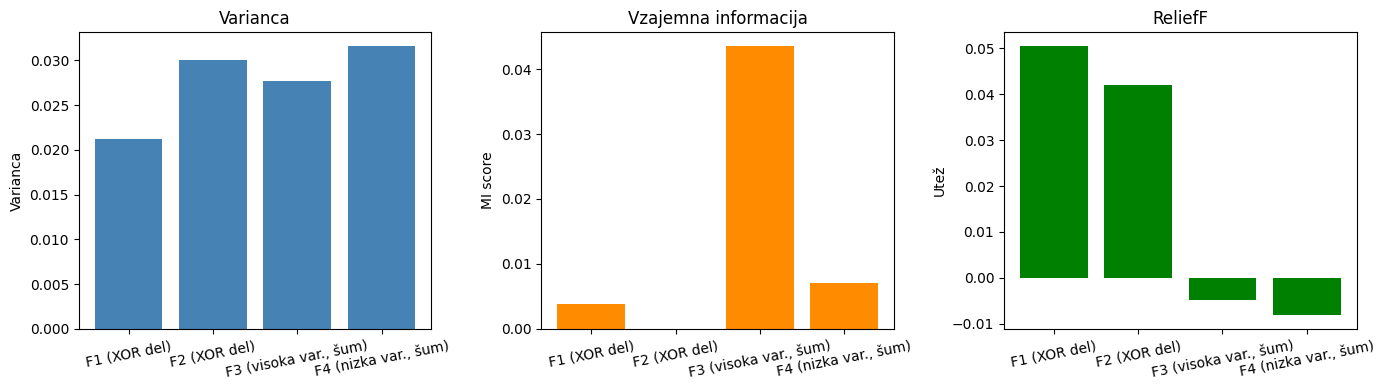

In [21]:
rng = np.random.default_rng(0)
n = 500
F1 = rng.normal(0, 1, n)
F2 = rng.normal(0, 1, n)
y_data = ((F1 * F2) > 0).astype(int)  # XOR: 1, če sta istega predznaka
F3 = rng.normal(0, 5, n)              # visoka varianca, neinformativna
F4 = rng.normal(0, 0.01, n)           # nizka varianca, neinformativna
X_data = np.column_stack([F1, F2, F3, F4])

feature_names = ["F1 (XOR del)", "F2 (XOR del)", "F3 (visoka var., šum)", "F4 (nizka var., šum)"]

# Dopolni
#Varianca
X_scaled = (X_data - X_data.min(axis=0)) / (X_data.max(axis=0) - X_data.min(axis=0))
variances = np.var(X_scaled, axis=0)

#Vzajemna informacija
mi_scores = mutual_info_classif(X_data, y_data, random_state=0) #MI score pomeni Mutual Information score (vzajemna informacija)

#ReliefF
feature_ranges = X_data.max(axis=0) - X_data.min(axis=0)
cat_mask = np.array([False, False, False, False])
relief_weights = relieff(X_data, y_data, n_iterations=n, k=10,
                         feature_ranges=feature_ranges,
                         categorical_mask=cat_mask,
                         rng=np.random.default_rng(0))

#Stolpični diagram
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(feature_names, variances, color="steelblue")
axes[0].set_title("Varianca")
axes[0].set_ylabel("Varianca")

axes[1].bar(feature_names, mi_scores, color="darkorange")
axes[1].set_title("Vzajemna informacija")
axes[1].set_ylabel("MI score")

axes[2].bar(feature_names, relief_weights, color="green")
axes[2].set_title("ReliefF")
axes[2].set_ylabel("Utež")

for ax in axes:
    ax.tick_params(axis='x', rotation=11)

plt.tight_layout()
plt.show()

**Odgovora:**
- Varianca in vzajemna info oba odpoveta, ker varianco oz. MI score merita za posamezno spremenljivko in zato nista sposobni ugotoviti povezavo med F1 in F2.
- ReliefF pa v primerjavi s drugima metodama nima te pomanjklivosti. Najbližje sosede išče na podlagi vseh spremenljivk, zato je zmožen prepoznati povezavo med F1 in F2.

### 2.e: Razprava

Odgovori na naslednji vprašanji:

1. Predstavljaj si, da podatkovni množici iz 2.d dodaš spremenljivko $F_5$, ki je natančna (ali skoraj natančna) kopija spremenljivke $F_1$. Kakšne uteži pričakuješ od ReliefF za $F_1$ in $F_5$? Je to dobro ali slabo za izbiro spremenljivk, če želimo na koncu uporabiti čim manj spremenljivk?

2. Kdaj (v kakšnih primerih) bi izbral vsakega od treh pristopov iz naloge 2.c?

**Odgovora:**
- F1 in F5 bosta dobili podobni, ampak nižji uteži kot bi F1 sama. To je slabo za izbiro spremenljivk, ker nas lahko pripelje do tega, da podcenimu njuno informativnost, čeprav sta isti.
- Varianco bi izbral pri nenadzorovanem učenju, kjer nimamo ciljne spremenljivke, in če hočemo odstraniti spremenljivke, ki so konstantne oz. imajo nizko varianco.  
Vzajmeno info bi uporabil, ko so spremenljivke neodvisne od drug druge.  
ReliefF pa bi uporabil, ko potebujem bolj robustno oceno. Ko so spremenljivke povezane, imamo več razredov, imamo tako numerične kot kategrične spremenljivke.  




## Naloga 3: Nelinearno krčenje razsežnosti in neuravnotežene množice

V tej nalogi se bomo hkrati soočali z dvema povezanima problemoma. Najprej bomo skrčili razsežnost podatkov s samokodirnikom in primerjali rezultate s PCA. Nato pa bomo vizualno ugotavljali, kako SMOTE vzorči nove primere in s tem pomaga pri uravnoteževanju porazdelitve vrednosti ciljne spremenljivke.

Za podatke bomo uporabili sklearnov `load_digits` — 1797 ročno napisanih števk velikosti $8 \times 8$ pikslov (64 napovednih spremenljivk).

### 3.a: Samokodirnik

Samokodirnike že poznaš z vaj — tukaj jih bomo uporabili kot nelinearno alternativo metodi analize glavnih komponent (PCA). Spomnimo se ključne razlike med PCA in samokodirnikom. Če sta kodirnik in dekodirnik linearna, samokodirnik preslika podatke v latentni nizkorazsežnostni prostor tako kot PCA. Z uporabo nelinearnih funkcij aktivacije v kodirniku in dekodirniku, se lahko samokodirnik nauči primere nelinearno transformirati v latentni prostor. Ta nelinearna transformacija je bistvo te naloge.

Dopolni razred `Autoencoder`, tako da bo implementiral kodirnik z arhitekturo `input_dim → 32 → 16 → latent_dim` in dekodirnik z zrcalno arhitekturo. V vseh plasteh, razen izhodni plasti dekodirnika, uporabi `nn.Tanh()`. V izhodni plasti dekodirnika pa uporabi `nn.Sigmoid()` (zato, da bodo vrednosti pikslov v intervalu $[0, 1]$).

In [22]:
import torch
import torch.nn as nn


class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=2):
        super().__init__()
        # Dopolni: kodirnik input_dim -> 32 -> 16 -> latent_dim (s Tanh med sloji)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.Tanh(),
            nn.Linear(32, 16),
            nn.Tanh(),
            nn.Linear(16, latent_dim),
            nn.Tanh()
        )
        # Dopolni: dekodirnik latent_dim -> 16 -> 32 -> input_dim (s Tanh med sloji, izhod sigmoid v [0, 1])
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.Tanh(),
            nn.Linear(16, 32),
            nn.Tanh(),
            nn.Linear(32, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Dopolni
        z = self.encoder(x)
        x_rec = self.decoder(z)
        return x_rec, z


def train_autoencoder(model, X, n_epochs=3000, lr=2e-3, verbose=True):
    """Učenje samokodirnika z MSE izgubo in Adam optimizatorjem."""
    # Dopolni
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    X_tensor = torch.tensor(X, dtype=torch.float32)
    train_loss = []
    for epoch in range(n_epochs):
        model.train()
        optim.zero_grad()
        x_rec, z = model(X_tensor)
        loss = loss_fn(x_rec, X_tensor)
        loss.backward()
        optim.step()
    
    return model, train_loss


# Hiter test
torch.manual_seed(0)
ae_test = Autoencoder(input_dim=64, latent_dim=2)
x_test = torch.rand(5, 64)
x_rec, z = ae_test(x_test)
print("Vhod:", x_test.shape, "→ latentni:", z.shape, "→ rekonstrukcija:", x_rec.shape)

Vhod: torch.Size([5, 64]) → latentni: torch.Size([5, 2]) → rekonstrukcija: torch.Size([5, 64])


### 3.b: Števke — PCA vs. samokodirnik

Naložimo podatkovno množico `sklearn.datasets.load_digits` in normalizirajmo vrednosti pikslov (napovednih spremenljivk) na interval $[0, 1]$ (delimo s 16, ker so vrednosti pikslov v intervalu $[0, 16]$).

Naredi naslednje:
1. Prikaži nekaj primerov števk (npr. po eno iz vsakega razreda).
2. Uporabi PCA za preslikavo podatkovne množice v dvodimenzionalni prostor.
3. Natreniraj samokodirnik z `latent_dim=2` in pridobi njegove dvodimenzionalne predstavitve primerov iz učne množice v latentnem prostoru.
4. Za vsako od teh dveh predstavitev nariši scatterplot enega ob drugem, kjer so točke pobarvane na osnovi števk, ki jih predstavljajo.

**Vprašanji:**
- Katera metoda bolje loči skupine primerov po razredih (števkah) in zakaj? Premisli kolikšno je najmanjše število komponent PCA, ki bi jih potrebovali zato, da dobro ločimo števke (razrede).
- Latentni prostor samokodirnika nikoli ni "prazen prostor": ko z dekodirnikom dekodiramo katero koli točko iz njega, dobimo nekakšno sliko, ki je videti kot števka (oziroma včasih kot kombinacija števk). Kako bi to lastnost izkoristili za generiranje novih primerov? Zakaj v originalnem 64-razsežnem prostoru slikovnih pik tak naivni pristop vzorčenja vrednosti 64 pikslov ne deluje (torej, zakaj v tem primeru večnimo ne bi dobili kombinacijo pikslov, kar bi tvorili nekaj, kar je podobno števki)?

**Odgovora:**
- Glede na spodnja scatterplota samokodirnk boljše loči skupnine. Razlog je v tem, da je PCA linearna metoda, podatki pa so nelinearni (števke so različnih debelin, ena je v primerjavi s drugo malo zarotirana, različni stil pisanja...). V samokodirniku pa smo uporabili nelinearno aktivacijsko funkcijo Tanh, in zato deluje bistveno boljše.  
Glede na graf narisan na koncu te podnaloge, dve komponenti pojasnita le med 20 in 40% skupne variance. Boljše bi bilo vzet vsaj 20 komponent, da bo skupni delež variance vsaj okrog 90%.
- Nove primere bi generirali, tako da bi naključno vzorčil točko iz latentnega prostora in jo dekodiral. Potem bi dobil novo sintetično sliko števke.  
Originalni 64-razsežen prostor je pre velik, da bi s njim generiral nove primere, zato bi ponavadi dobili nek naključen šum. Latentni prostor pa je manjši 2D prostor, kjer imamo dobro možnost, da pri naključnem vzorčenju dobimo števko.


Število primerov: 1797, dimenzija: 64


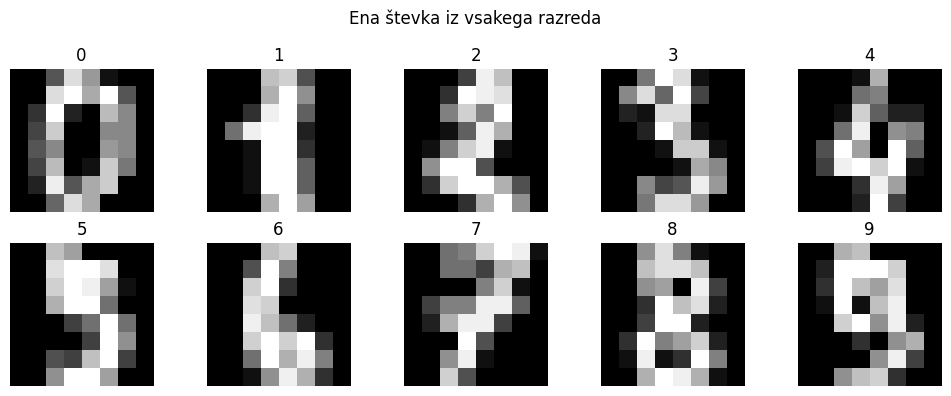

In [23]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

digits = load_digits()
X_digits = digits.data / 16.0       # piksli 0..16  ->  0..1
y_digits = digits.target
print(f"Število primerov: {X_digits.shape[0]}, dimenzija: {X_digits.shape[1]}")

# Dopolni

#1. Prikaži nekaj primerov
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit in range(10):
    idx = np.where(y_digits == digit)[0][0] #dobiš prvi primer vsakega razreda
    ax = axes[digit // 5][digit % 5]
    ax.imshow(X_digits[idx].reshape(8, 8), cmap="gray")
    ax.set_title(digit)
    ax.axis("off")

plt.suptitle("Ena števka iz vsakega razreda")
plt.tight_layout()
plt.show()

In [24]:
#2 Uporabimo PCA za preslikavo v 2D
pca = PCA(n_components=2) #reduciramo iz 64D na 2D
X_pca = pca.fit_transform(X_digits)
print(f"Oblika PCA predstavitve: {X_pca.shape}")


Oblika PCA predstavitve: (1797, 2)


In [25]:
#3 Treniranje samokodirnika
torch.manual_seed(0)
ae = Autoencoder(input_dim=64, latent_dim=2)
X_tensor = torch.tensor(X_digits, dtype=torch.float32)
ae, train_loss = train_autoencoder(ae, X_digits, n_epochs=3000, lr=2e-3)

#latentne predstavitve
ae.eval()
with torch.no_grad():
    _, Z_ae = ae(X_tensor)

Z_ae = Z_ae.numpy()
print(f"Oblika latentne predstavitve: {Z_ae.shape}")

Oblika latentne predstavitve: (1797, 2)


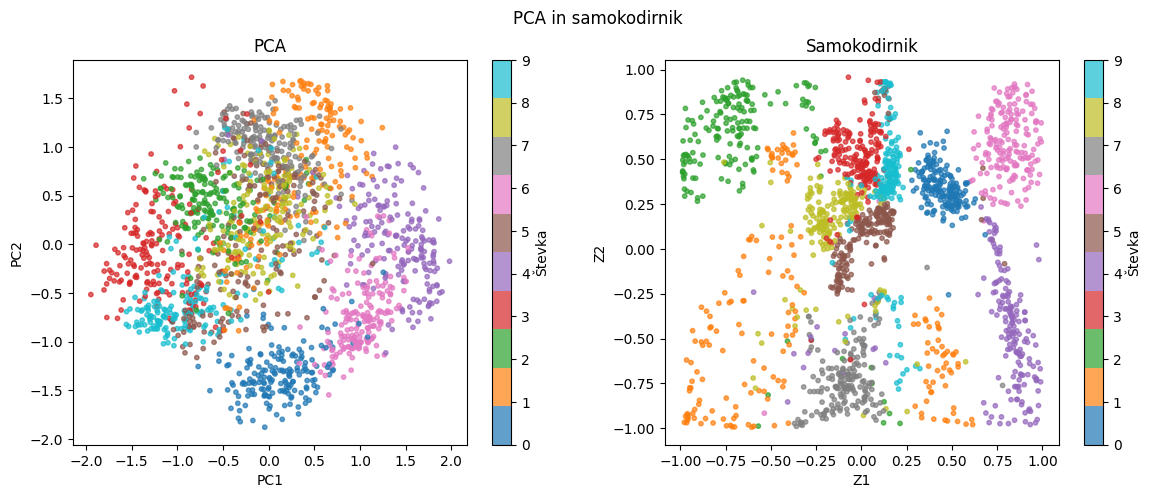

In [26]:
#4 Scatterplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#PCA
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_digits, cmap="tab10", s=10, alpha=0.7)
axes[0].set_title("PCA")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
plt.colorbar(scatter1, ax=axes[0], label="Števka")

#Samokodirnik
scatter2 = axes[1].scatter(Z_ae[:, 0], Z_ae[:, 1], c=y_digits, cmap="tab10", s=10, alpha=0.7)
axes[1].set_title("Samokodirnik")
axes[1].set_xlabel("Z1")
axes[1].set_ylabel("Z2")
plt.colorbar(scatter2, ax=axes[1], label="Števka")

plt.suptitle("PCA in samokodirnik")
plt.show()

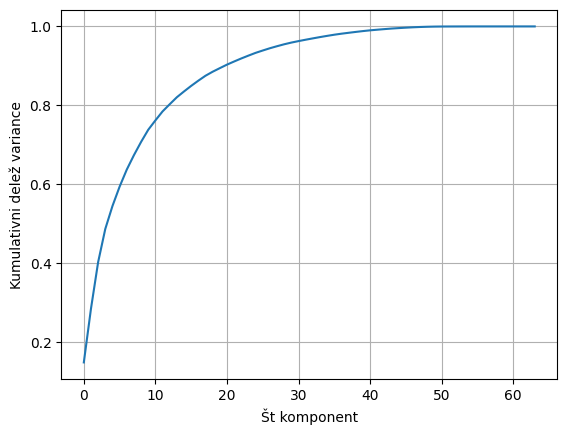

In [27]:
#Spodnji graf pomaga odgovoriti na drugi del prvega vprašanja.
pca_full = PCA().fit(X_digits)
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.plot(cumulative_var)
plt.xlabel("Št komponent")
plt.ylabel("Kumulativni delež variance")
plt.grid()
plt.show()

### 3.c: Neuravnoteženost in SMOTE — vizualno

Sedaj iz podatkovne množice števk sestavimo podatkovno množico za binarno klasifikacijo in v njej ustvarimo močno neuravnoteženost med razredoma takole. Izberemo dve podobni si števki (npr. 3 in 8) ter vzamemo zgolj 5 % primerov za eno od števk in vse primere za drugo števko. V tako dobljeni množici bo razmerje primerov v enem in drugem razredu približno $95\!:\!5$.

V tej nalogi se bomo osredotočili izključno na vizualizacijo manjšinskega razreda. Klasifikatorja ne treniramo: zanima nas, kako se porazdelitev vrednosti napovednih spremenljivk v dodanih primerih (sintetičnih primerih ali duplikatih) manjšinskega razreda ujemajo s pravo porazdelitvijo vrednosti napovednih spremenljivk v pravih primerih iz tega razreda. Slednjo ocenimo iz množice vseh pravih števk iz istega razreda, tudi tistimi, ki smo jih izpustili pri vzorčenju nove podatkovne množice.

Trije pristopi (uporabi knjižnico [imbalanced-learn](https://imbalanced-learn.org/)):
1. Brez popravkov — pustimo neuravnoteženo.
2. Naključno nadvzorčenje (`imblearn.over_sampling.RandomOverSampler`) — primere manjšinskega razreda preprosto podvajamo.
3. SMOTE (`imblearn.over_sampling.SMOTE`) — za vsak manjšinski primer poišče $k$ najbližjih sosedov istega razreda in generira sintetičen primer kot naključno interpolacijo:
$$x_{\text{nov}} = x_i + \lambda \cdot (x_{\text{sosed}} - x_i), \quad \lambda \sim \mathcal{U}(0, 1).$$

Naredi naslednje:
1. S samokodirnikom iz 3.b preslikaj v dvodimenzionalni latentni prostor naslednje primere:
   - vse prave primere manjšinskega razreda (kot referenca — to je porazdelitev, ki bi jo videli, če bi imeli vse podatke),
   - primere manjšinjskega razreda, ki smo jih vzorčili v novo podatkovno množico (tistih 5 %),
   - dodane primere (z naključnim vzorčenjem duplikatov in z uporabo SMOTE).
   Nariši tri scatter grafe enega ob drugem (vzorec / + duplilkati / + SMOTE) in jasno loči vse vrste točk, ki so za to množico aplikabilni.
2. Vizualiziraj nekaj primerov manjšinskega razreda kot $8 \times 8$ slike v štirih vrsticah: prave (neuporabljene), vzorčene, naključno vzorčeni duplikati, in sintetični SMOTE primeri.

**Vprašanji:**

- Pri SMOTE: ali so dodani sintetični primeri znotraj referenčne porazdelitve pravih manjšinskih primerov, ali izven nje? Kaj to pove o kakovosti novih sintetičnih primerov?
- SMOTE interpolira v originalnem 64-razsežnem prostoru slikovnih pik. Premisli: če bi pred SMOTE projecirali podatke v latentni prostor samokodirnika in šele tam interpolirali nove predstavitve, ki bi jih nato dekodirali nazaj v slike, bi pričakovali boljše ali slabše sintetične primere? Zakaj? (Namig: razmisli o drugem vprašanju iz 3.b — kaj se zgodi, če interpoliramo med slikama, ki ležita v različnih delih mnogoterosti smiselnih števk?)

**Odgovora:**
- Dodani sintetični primeri so večinoma znotraj ref porazdelitve, razen za dve precej opaznih črti zelenih točk, ki gresta do modrih točk. Zato lahko rečemo, da so novi sintetični primeri dobre kakovosti, ampak vseeno pa ne idealni.
- Pričakovali bi boljše sintetične primere. V orignalnem 64D prostoru SMOTE vzame povprečje dveh osmic za vsak piksel, kar lahko vodi do zamegljene/nejasne slike (če je npr ena osmica nagnjena na levo druga pa na desno). V latentnem prostoru pa so si podobne osmice blizu, zato SMOTE interpolira med točkami, ki so si vizualno podobne. Posedično je rekonstruirana slika boljša.


Vzorec: [183   9] (vzorčili smo 9 od 174 pravih '8')
Brez popravkov: [183   9]
RandomOverSampler: [183 183]
SMOTE: [183 183]


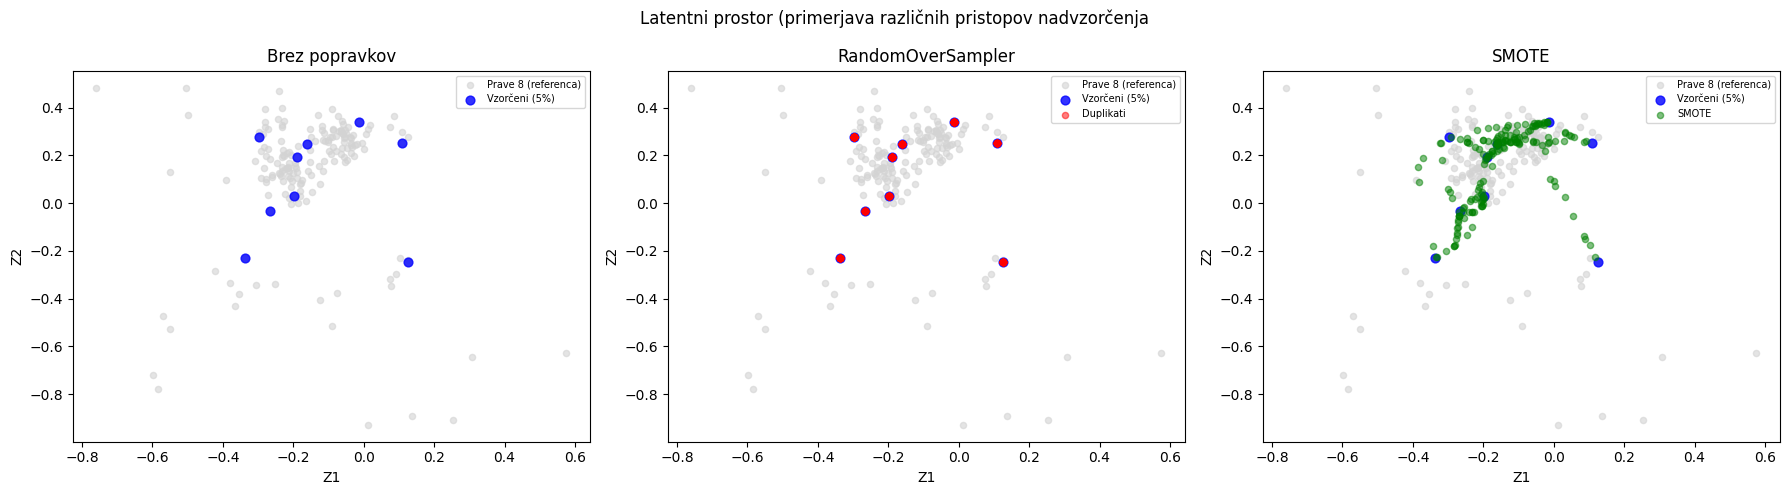

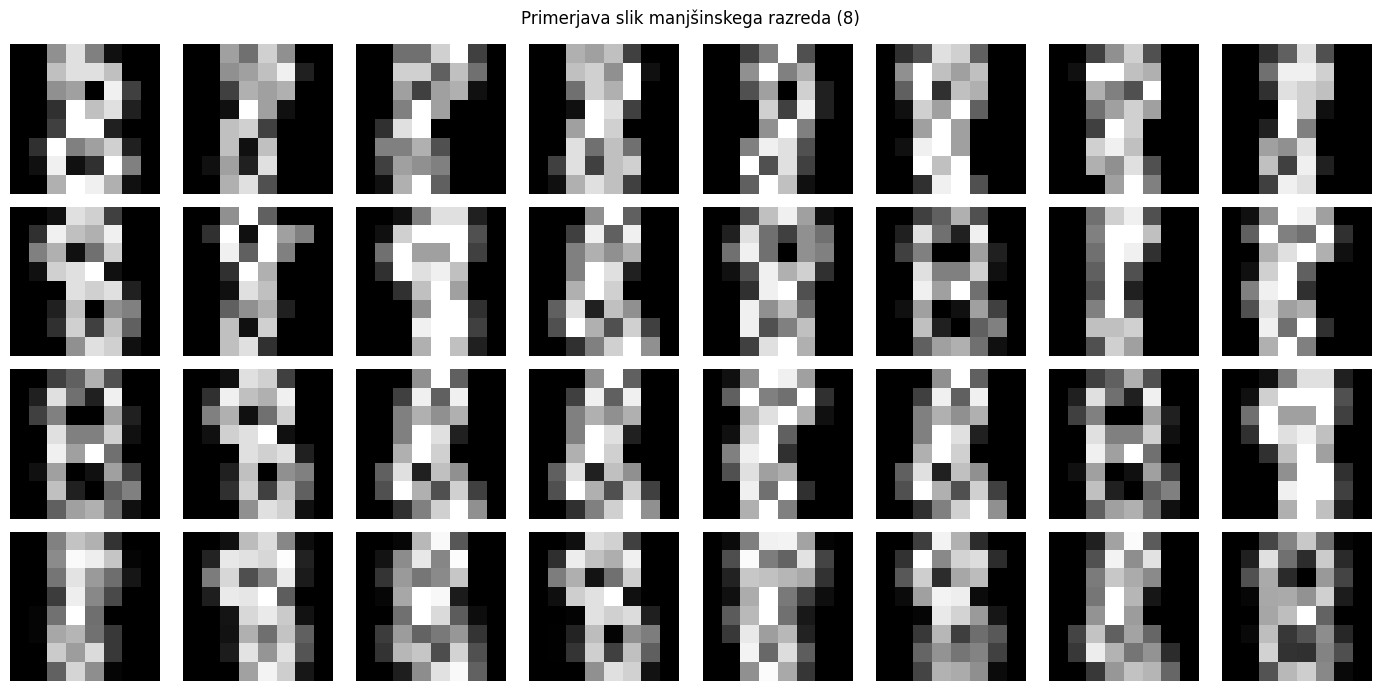

In [28]:
from imblearn.over_sampling import RandomOverSampler, SMOTE

# 1. Izberi dva razreda (3 in 8) in ustvari neuravnoteženost; sledimo, katere prave 8 smo izpustili
CLASS_A, CLASS_B = 3, 8                  # CLASS_B bo manjšina
mask = np.isin(y_digits, [CLASS_A, CLASS_B])
X_pair = X_digits[mask]
y_pair = (y_digits[mask] == CLASS_B).astype(int)

rng = np.random.default_rng(0)
idx_majority = np.where(y_pair == 0)[0]
idx_minority_full = np.where(y_pair == 1)[0]
n_keep = int(0.05 * len(idx_majority) / 0.95)
idx_minority_keep = rng.choice(idx_minority_full, size=n_keep, replace=False)
idx_minority_heldout = np.setdiff1d(idx_minority_full, idx_minority_keep)
idx_keep = np.concatenate([idx_majority, idx_minority_keep])

X_imb = X_pair[idx_keep]
y_imb = y_pair[idx_keep]
print(f"Vzorec: {np.bincount(y_imb)} (vzorčili smo {n_keep} od {len(idx_minority_full)} pravih '{CLASS_B}')")

# Dopolni

#Brez popravkov
X_none, y_none = X_imb, y_imb
#RandomOverSampler
ros = RandomOverSampler(random_state=0)
X_ros, y_ros = ros.fit_resample(X_imb, y_imb)
#SMOTE
smote = SMOTE(random_state=0, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_imb, y_imb)

print(f"Brez popravkov: {np.bincount(y_none)}")
print(f"RandomOverSampler: {np.bincount(y_ros)}")
print(f"SMOTE: {np.bincount(y_smote)}")

ae.eval()
with torch.no_grad():
    #Vse prave primere za 8
    X_minority_full = X_pair[idx_minority_full]
    Z_full = ae.encoder(torch.tensor(X_minority_full, dtype=torch.float32)).numpy()
    #Tistih 5%
    X_minority_keep = X_pair[idx_minority_keep]
    Z_keep = ae.encoder(torch.tensor(X_minority_keep, dtype=torch.float32)).numpy()
    #Duplikati
    X_ros_added = X_ros[len(X_imb):]
    Z_ros_added = ae.encoder(torch.tensor(X_ros_added, dtype=torch.float32)).numpy()
    #SMOTE primeri
    X_smote_added = X_smote[len(X_imb):]
    Z_smote_added = ae.encoder(torch.tensor(X_smote_added, dtype=torch.float32)).numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titles = ["Brez popravkov", "RandomOverSampler", "SMOTE"]

for i, (ax, title) in enumerate(zip(axes, titles)):
    #Referenca
    ax.scatter(Z_full[:, 0], Z_full[:, 1], 
               c="lightgray", s=20, alpha=0.6, label="Prave 8 (referenca)")
    #Vzorčeni pravi primeri
    ax.scatter(Z_keep[:, 0], Z_keep[:, 1], 
               c="blue", s=40, alpha=0.8, label="Vzorčeni (5%)")
    #Dodani primeri
    if i == 1:
        ax.scatter(Z_ros_added[:, 0], Z_ros_added[:, 1],
                   c="red", s=20, alpha=0.5, label="Duplikati")
    elif i == 2:
        ax.scatter(Z_smote_added[:, 0], Z_smote_added[:, 1],
                   c="green", s=20, alpha=0.5, label="SMOTE")
    
    ax.set_title(title)
    ax.set_xlabel("Z1")
    ax.set_ylabel("Z2")
    ax.legend(fontsize=7)

plt.suptitle("Latentni prostor (primerjava različnih pristopov nadvzorčenja")
plt.tight_layout()
plt.show()

#Vizualizacija primerov
n_show = 8
fig, axes = plt.subplots(4, n_show, figsize=(14, 7))
row_titles = ["Prave (neizpuščene)", "Vzorčene (5%)", "Duplikati", "SMOTE"]
#Prave neizpuščene
X_heldout = X_pair[idx_minority_heldout]
for j in range(n_show):
    axes[0, j].imshow(X_heldout[j].reshape(8, 8), cmap="gray")
    axes[0, j].axis("off")
#Vzorčene
for j in range(n_show):
    axes[1, j].imshow(X_minority_keep[j].reshape(8, 8), cmap="gray")
    axes[1, j].axis("off")
#Duplikati
for j in range(n_show):
    axes[2, j].imshow(X_ros_added[j].reshape(8, 8), cmap="gray")
    axes[2, j].axis("off")
#SMOTE
for j in range(n_show):
    axes[3, j].imshow(X_smote_added[j].reshape(8, 8), cmap="gray")
    axes[3, j].axis("off")

for i, title in enumerate(row_titles):
    axes[i, 0].set_ylabel(title, fontsize=10, rotation=90, labelpad=40)

plt.suptitle("Primerjava slik manjšinskega razreda (8)")
plt.tight_layout()
plt.show()

1. vrstica: Prave
2. vrstica: Vzorčene (5%)
3. vrstica: Duplikati
4. vrstica: SMOTE

## Naloga 4: Odprta naloga

V datoteki `dn3_cracked.csv` je podana podatkovna množica, kjer primeri ustrezajo študentom. Tvoja naloga je sestaviti napovedni model, ki glede na smiselno izbrano metriko čim bolje napove, ali je študent študij končal, ga še vedno opravlja, ali je s študijem prenehal (to so vrednosti v zadnjem stolpcu z naslovom `Target`).

Celoten postopek in vse poskuse (tudi neuspešne) zabeleži in o njih poročaj.

> Pozor: Ne predpostavljaj, da so podatki čisti. Izbira mere uspešnosti, postopek delitve podatkov in obravnava razredne neuravnoteženosti so del naloge — vse svoje odločitve dobro premisli in tudi pisno utemelji v oddani rešitvi.

Podatkovna množica vsebuje naslednje spremenljivke:

- Zakonski stan: kategorični
- Vrsta vloge: kategoričen
- Vrstni red vloge: int
- Tečaj: kategoričen
- Prisotnost podnevi/zvečer: kategorična
- Prejšnja kvalifikacija: kategorična
- Prejšnja kvalifikacija (ocena): float
- Državljanstvo: kategorialno
- Materina kvalifikacija: kategorična
- Očetova kvalifikacija: kategorična
- Poklic matere: kategoričen
- Poklic očeta: kategoričen
- Ocena pri vpisu: float
- Preseljen: kategorično
- Posebne izobraževalne potrebe: kategorično
- Dolžnik: kategorično
- Šolnine do datuma: kategorično
- Spol: kategorično
- Zadnje tri številke študentske izkaznice: int
- Štipendist: kategorično
- Starost ob vpisu: int
- Tujec: kategorično
- Učne enote 1. semester (priznane): int
- Učne enote 1. semester (vpisane): int
- Učne enote 1. semester (ocene): int
- Učne enote 1. semester (odobrene): int
- Učne enote 1. semester (ocena): float
- Učne enote 1. semester (brez ocen): int
- Učne enote 2. semester (priznane): int
- Učne enote 2. semester (vpisane): int
- Učne enote 2. semester (ocene): int
- Učne enote 2. semester (odobrene): int
- Učne enote 2. semester (ocena): float
- Učne enote 2. semester (brez ocen): int
- Stopnja brezposelnosti: float
- Stopnja inflacije: float
- BDP: float
- Standardiziran rezultat sprejemnega testa: float
- Indeks socioekonomskega statusa: float
- Anketni rezultat zadovoljstva: float
- Povprečna ocena srednje šole (normalizirana): float
- Indeks oddaljenosti od fakultete: float
- Mesečni dohodek staršev (z-score): float
- Rezultat psihološkega testa A: float
- Rezultat psihološkega testa B: float
- Indeks delovne obremenitve: float
- Število ur učenja na teden (z-score): float
- Indeks digitalne pismenosti: float
- Rezultat preverjanja angleščine: float
- Ocena motivacijskega pisma: float
- Indeks zdravstvenega stanja: float
- Rezultat testa logičnega sklepanja: float
- Številka prijave: int
- Šifra mentorja: int
- Številka razreda v srednji šoli: int
- Poštna številka: int
- Šifra študijskega programa: int
- Ciljna vrednost (`Target`): kategoričen


### 4.a: Nalaganje podatkov in prvi pregled

Preden zgradimo kakršenkoli model, moramo razumeti s čim imamo opravka. Ime datoteke (`dn3_cracked.csv`) namiguje, da podatki niso čisti, zato najprej preverimo: obliko, tipe stolpcev, manjkajoče vrednosti, podvojene vrstice in porazdelitev ciljne spremenljivke (`Target`).

In [41]:
import pandas as pd

df = pd.read_csv("dn3_cracked.csv", sep=";")

print("Oblika:", df.shape)
print("\nPorazdelitev Target:")
print(df["Target"].value_counts())
print("\nDelež manjkajočih vrednosti po stolpcih (samo tisti > 0):")
missing = df.isna().mean().sort_values(ascending=False)
print(missing[missing > 0])
print("\nŠtevilo podvojenih vrstic:", df.duplicated().sum())
print("\nTipi stolpcev:")
print(df.dtypes.value_counts())

Oblika: (1875, 58)

Porazdelitev Target:
Target
Dropout     1406
Enrolled     375
Graduate      94
Name: count, dtype: int64

Delež manjkajočih vrednosti po stolpcih (samo tisti > 0):
Admission grade                                   0.120000
Daytime/evening attendance                        0.118933
Curricular units 2nd sem (credited)               0.118400
Curricular units 2nd sem (enrolled)               0.117867
Curricular units 1st sem (grade)                  0.117333
Curricular units 2nd sem (evaluations)            0.116800
Course                                            0.116267
Gender                                            0.115733
Application mode                                  0.115200
Father's qualification                            0.114667
Curricular units 2nd sem (approved)               0.114133
Scholarship holder                                0.114133
Marital status                                    0.113600
Curricular units 2nd sem (grade)                 

**Opažanja iz prvega pregleda:**

- Podatkovna množica ima 1875 primerov in 58 stolpcev (57 napovednih + `Target`). Podvojenih vrstic ni.
- `Target` je **neuravnotežen** trirazredni problem: `Dropout` (~75 %), `Enrolled` (~20 %), `Graduate` (~5 %). To bo pomembno pri izbiri metrike in morebitni obravnavi neuravnoteženosti.
- Približno 30 od 57 stolpcev ima okoli **11 % manjkajočih vrednosti** (naključno "izbita" na videz), preostalih ~20 stolpcev nima nobene manjkajoče vrednosti. Manjkajočih vrednosti torej ne moremo preprosto ignorirati (izpustili bi ~90 % vrstic, če bi izbrisali vsako vrstico z vsaj eno manjkajočo vrednostjo) — potrebna bo imputacija.
- Vsi stolpci so numerični (`int64`/`float64`) — tudi tisti, ki so po opisu **kategorični** (npr. `Marital status`, `Course`, `Gender` ...), so v resnici zakodirani s številkami. Te moramo eksplicitno obravnavati kot kategorije (one-hot), sicer bi model privzel, da imajo (nesmiselni) linearni/urejenostni odnos.
- V podatkih so tudi očitno **identifikacijski stolpci** brez prave napovedne vrednosti (`Application number`, `Mentor code`, `Last three digits of the ID`, `Postal code`, `Study program code`, `High school class number`) — to so praktično naključne šifre/oznake, ne značilnosti študenta. Te bomo izločili, saj bi njihovo vključevanje lahko škodovalo posplošitvi (model bi se lahko navidezno "naučil" nesmiselnih vzorcev na specifičnih ID-jih učne množice).
- Opazimo tudi skupino stolpcev tipa "indeks"/"z-score"/"rezultat testa" (npr. `Psychological test A/B score`, `Digital literacy index`, `Health status index`, `Workload index` ...), ki **nimajo nobene manjkajoče vrednosti** — v izvirni UCI množici "Predict students' dropout and academic success", na kateri ta naloga verjetno temelji, teh spremenljivk ni. Možno je, da gre za dodan šum; to bomo preverili v naslednjem koraku z izbiro napovednih spremenljivk (npr. z metodami iz Naloge 2), namesto da jih kar avtomatično izločimo brez preverjanja.

### 4.b: Prvi (osnovni) model — logistična regresija

Za začetek zgradimo preprost, a korekten **osnovni model (baseline)**: multinomsko logistično regresijo. Ta nam bo služila kot referenca, na kateri bomo v nadaljevanju (dodatni poskusi, izbira spremenljivk, obravnava neuravnoteženosti, morebitni močnejši modeli) presojali, ali izboljšave dejansko pomagajo.

Odločitve za ta prvi poskus:
- **Izločimo ID-jem podobne stolpce** (`Application number`, `Mentor code`, `Last three digits of the ID`, `Postal code`, `Study program code`, `High school class number`) — glede na zgornja opažanja gre za šifre brez napovedne vrednosti.
- **Kategorične spremenljivke** kodiramo z one-hot (`OneHotEncoder`), **numerične** pa standardiziramo (`StandardScaler`) po imputaciji manjkajočih vrednosti (mediana za numerične, najpogostejša vrednost za kategorične) — logistična regresija je občutljiva na razpon spremenljivk, standardizacija pa poleg tega pomaga optimizatorju h konvergenci.
- **Delitev na učno in testno množico**: 80/20, **stratificirano** po `Target`, ker je razred `Graduate` redek (~5 %) — brez stratifikacije bi lahko testna množica vsebovala premalo (ali nič) primerov tega razreda za smiselno oceno.
- **Neuravnoteženost razredov**: v tem prvem poskusu jo naslovimo najpreprosteje možno, z `class_weight="balanced"` v logistični regresiji (uteži primerov obratno sorazmerne s pogostostjo razreda), namesto vzorčenja (SMOTE ipd.) — to pustimo za kasnejšo primerjavo.
- **Metrika**: ker so razredi neuravnoteženi in nas zanima uspešnost na vseh treh razredih (ne le na večinskem `Dropout`), kot glavno metriko izberemo **macro F1** (enako uteži vse razrede ne glede na velikost). Dodatno spremljamo tudi *balanced accuracy* in poln `classification_report` (precision/recall/F1 po razredih), ker macro F1 sam po sebi ne pove, kje model dela napake.

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# Stolpci, ki so v resnici (skoraj gotovo naključne) šifre/identifikatorji, ne prave značilnosti
id_cols = [
    "Application number", "Mentor code", "Last three digits of the ID",
    "Postal code", "Study program code", "High school class number",
]

# Kategorične spremenljivke (zakodirane kot številke, a nimajo urejenostnega pomena)
categorical_cols = [
    "Marital status", "Application mode", "Course", "Daytime/evening attendance",
    "Previous qualification", "Nationality", "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation", "Displaced", "Educational special needs",
    "Debtor", "Tuition fees up to date", "Gender", "Scholarship holder", "International",
]

y = df["Target"]
X = df.drop(columns=id_cols + ["Target"])
categorical_cols = [c for c in categorical_cols if c in X.columns]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

print(f"Napovednih spremenljivk: {X.shape[1]} ({len(categorical_cols)} kategoričnih, {len(numeric_cols)} numeričnih)")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=0
)
print(f"Učna množica: {X_train.shape[0]}, testna množica: {X_test.shape[0]}")
print("Porazdelitev razredov v učni množici:")
print(y_train.value_counts(normalize=True))

Napovednih spremenljivk: 51 (17 kategoričnih, 34 numeričnih)
Učna množica: 1500, testna množica: 375
Porazdelitev razredov v učni množici:
Target
Dropout     0.75
Enrolled    0.20
Graduate    0.05
Name: proportion, dtype: float64


In [43]:
preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_cols),
])

baseline_model = Pipeline([
    ("preprocess", preprocess),
    ("logreg", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=0)),
])

baseline_model.fit(X_train, y_train)
y_pred = baseline_model.predict(X_test)

              precision    recall  f1-score   support

     Dropout      0.940     0.726     0.819       281
    Enrolled      0.438     0.653     0.524        75
    Graduate      0.261     0.632     0.369        19

    accuracy                          0.707       375
   macro avg      0.546     0.670     0.571       375
weighted avg      0.805     0.707     0.737       375

Macro F1: 0.571
Balanced accuracy: 0.670


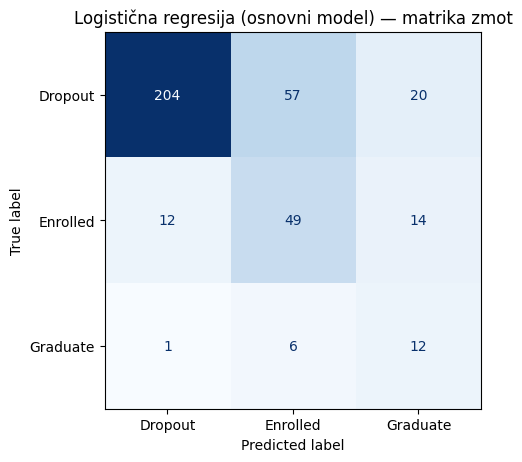

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score, balanced_accuracy_score, ConfusionMatrixDisplay

print(classification_report(y_test, y_pred, digits=3))
print(f"Macro F1: {f1_score(y_test, y_pred, average='macro'):.3f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred):.3f}")

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, labels=baseline_model.classes_, cmap="Blues", ax=ax, colorbar=False
)
ax.set_title("Logistična regresija (osnovni model) — matrika zmot")
plt.tight_layout()
plt.show()

**Rezultati osnovnega modela (logistična regresija, `class_weight="balanced"`):**

- Macro F1 ≈ 0.57, balanced accuracy ≈ 0.67, splošna točnost ≈ 0.71.
- Razred `Dropout` (večinski) ima visok precision (~0.94), a nižji recall (~0.73) — `class_weight="balanced"` model "potisne" v smer boljšega prepoznavanja manjšinskih razredov na račun nekaj več napačno označenih `Dropout` primerov kot `Enrolled`/`Graduate`.
- Razred `Graduate` (najmanjši, ~5 %) je pričakovano najšibkejši (F1 ~0.37) — najmanj primerov za učenje, poleg tega ga matrika zmot kaže kot najbolj zamenljivega z `Enrolled`, kar je smiselno (oba sta "ne-Dropout" izida in si delita marsikatero značilnost).

**To je zavestno le prvi, osnovni poskus** — služi kot referenčna točka. Odprta vprašanja, ki jih velja raziskati v nadaljevanju (in jih je treba po navodilih naloge tudi dokumentirati, četudi se izkažejo za neuspešne):

1. Ali "sumljivi" stolpci brez manjkajočih vrednosti (psihološki testi, razni indeksi ...) dejansko nosijo napovedno moč, ali gre za šum? (preveriti npr. z ReliefF/vzajemno informacijo iz Naloge 2, oz. s primerjavo modela z/brez njih)
2. Primerjava `class_weight="balanced"` z alternativami za neuravnoteženost (SMOTE, naključno pod/nad-vzorčenje) — katera dá boljši macro F1?
3. Primerjava z drugimi modeli (npr. random forest, gradient boosting) — je linearna meja logistične regresije zadostna, ali obstajajo pomembne nelinearnosti/interakcije med spremenljivkami?
4. Navzkrižna validacija (npr. stratificiran K-fold) namesto ene same delitve train/test, za bolj zanesljivo oceno metrik (trenutna ocena temelji na enkratni 20 % testni množici, kar je za razred `Graduate` s ~19 primeri v testu precej šumno).

# MOJE REŠEVANJE NALOGE

### Metrika za ocenjevanje modelov
Strinjam se z odločitvijo pri nalgo 4.b, da bi kot glavno metriko
za ocenjevanje modelv uporabil **macro F1** (predvsem zaradi neuravnoteženih razredov), zato bom jo tudi vnaprej obdržal.

### Stratificirana navzkrižna validacija
Začnimo z delitvijo množice s **stratificirano navzrkrižno validacijo**.  
- **Zakaj?**: 
    - stratifcirno po `Target` is enakih razlogov kot so navedeni pri nalgi 4b.
    - navzkrižna validacija pa zaradi robustnejše ocene napake.  
    Pri tem sem nastavil
      n_splits=5, ker pri večjem številu bi se lahko ocena manjšinskega razred 
      `Graduate` zašumela.  
      Prav tako sem nastavil nastavil parameter shuffle=True in s tem zagotovil,
      da foldi niso odvisni od kakšne posebne urejenosti vrstic glede na značilke X.

In [45]:
import numpy as np
from sklearn.model_selection import StratifiedKFold

In [46]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

errors1 = []
errors2 = []

for i, (train_index, test_index) in enumerate(kfold.split(X, y)):
    x_train = X.iloc[train_index, :]
    y_train = y.iloc[train_index]

    x_test = X.iloc[test_index]
    y_test = y.iloc[test_index]

    baseline_model.fit(x_train, y_train)
    y_pred = baseline_model.predict(x_test)

    error1 = f1_score(y_test, y_pred, average='macro')
    error2 = balanced_accuracy_score(y_test, y_pred)

    errors1.append(error1)
    errors2.append(error2)

    print(f"Fold {i}: Macro F1: {error1}, Balanced accuracy: {error2}")

print(f"Povprečen Macro F1: {np.mean(errors1):.3f}, "
      f"povprečen Balanced accuracy: {np.mean(errors2):.3f}")

    


Fold 0: Macro F1: 0.48201485068034605, Balanced accuracy: 0.5248384554767535
Fold 1: Macro F1: 0.5579080907725409, Balanced accuracy: 0.6257351563963289
Fold 2: Macro F1: 0.5817613875508005, Balanced accuracy: 0.672318161952925
Fold 3: Macro F1: 0.5416454087401739, Balanced accuracy: 0.6204715822771639
Fold 4: Macro F1: 0.5331383594298331, Balanced accuracy: 0.6496122869451209
Povprečen Macro F1: 0.539, povprečen Balanced accuracy: 0.619


Vidimo, da sta povp. Macro F1 in povp. Balanced accuracy manjša kot na 
prejšnji 80/20 delitvi množice.  
- Razpon povp. Macro F1: 0.482-0.582,
- Razpon popvp. Balanced acc.: 0.525-0.672.  

Obe originalnivi oceni pa vseeno padete v ta razpon (proti zgornji meji).  
Nižji oceni v tem primeru pa **nista slabost**. Sta bolj zaneslijivi
oceni od originalnih. Originalni sta bili nekoliko optimistični.

### Preverjanje napovedne moči stolpcev

Poglejmo si napovedno moč stolpcev s algoritmom ReliefF.

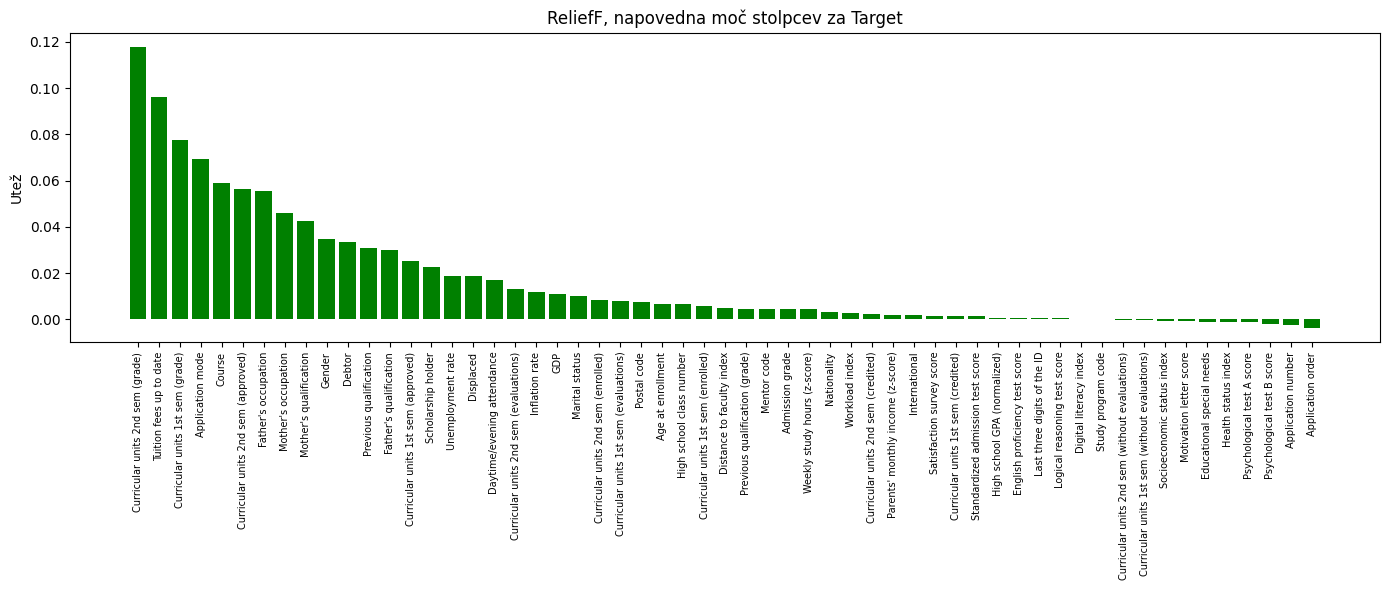

In [47]:
# Priprava podatkov za ReliefF (imputacija kot v 4.b)
X_all = df.drop(columns=["Target"])
cat_cols_all = [c for c in categorical_cols if c in X_all.columns]
num_cols_all = [c for c in X_all.columns if c not in cat_cols_all]

relief_imputer = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols_all),
    ("cat", SimpleImputer(strategy="most_frequent"), cat_cols_all),
], verbose_feature_names_out=False).set_output(transform="pandas")

X_imputed = relief_imputer.fit_transform(X_all)
feature_names = list(X_imputed.columns)
categorical_mask = np.array([c in cat_cols_all for c in feature_names])
feature_ranges = (X_imputed.max() - X_imputed.min()).to_numpy()
X_rel = X_imputed.to_numpy(dtype=float)
y_rel = df["Target"].to_numpy()

# ReliefF
relief_weights = relieff(
    X_rel, y_rel, n_iterations=len(y_rel), k=5,
    feature_ranges=feature_ranges, categorical_mask=categorical_mask,
    rng=np.random.default_rng(0),
)

# stolpični diagram
order = np.argsort(relief_weights)[::-1]
names_sorted = np.array(feature_names)[order]
weights_sorted = relief_weights[order]

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(names_sorted, weights_sorted, color="green")
ax.set_title("ReliefF, napovedna moč stolpcev za Target")
ax.set_ylabel("Utež")
ax.tick_params(axis="x", rotation=90, labelsize=7)
plt.tight_layout()
plt.show()



Prvih 24 stolpcev s največjo utežjo so vsi originalni stolpci iz mn. UCI.

Prvi presenetljiv rezultat je to, da npr. “Postal code“ ima večjo utež od značilk kot sta “Age at enrollment“ in “Admissision grade“. To ne pomeni nujno, da je ta značilka dejansko močnejša, ampak lahko namiguje na pokvarjenost nekaterih stolpcev iz dn3_craked. “Admissision grade“ še posebej bi v teoriji pričakoval, da bi imel večju dejanko utež za napoved kot jo ima.

Zaradi nizke uteži bom **značike, ki so šifre/identifikatorji v nadeljevanji izpustil** kot v nalogi 4b.

“Sumljiv“ stolpci brez manjkajočih vrendosti (Logical reasoning test score, Digital literacy index, Psychological test A score, Socioeconomic status index, Parents' monthly income (z-score), Motivation letter score, Health status index, Distance to faculty index, High school GPA (normalized), Weekly study hours (z-score), Satisfaction survey score, English proficiency test score, Workload index, Standardized admission test score, Psychological test B score)
imajo tudi nizko utež, kar podpre domnevo iz točke 1. naloge 4.b, da te značilke dejansko predstvaljajo šum. Zato jih bom enako kot šifre/identifikatorje **v naprej izpustil** 

Vredno je omeniti, da Standardized admission test score, Psychological test B score imata tudi manjkajoče vrednsosti, ampak ker sta podobna vrsta značik kot ostale “sumljive“ značilke je razlog za manjkajočimi vrednosti to, da bi bili zamaskirani kot originalni značilki iz UCI. Ti zančilki bom, torej tudi izločil.

**Kateri stolpci torej ostanejo?**
- ostanejo originalne značilke iz množice UCI. 

### Osnovni model (logistična regresija) le z značilkami iz UCI
Primerjajmo rezultate logistične regresije s in brez “sumljivih“ stolpcev.

In [48]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("dn3_cracked.csv", sep=";")

sumljivi_cols = [
    "Logical reasoning test score", "Digital literacy index", "Psychological test A score",
    "Socioeconomic status index", "Parents' monthly income (z-score)", "Motivation letter score",
    "Health status index", "Distance to faculty index", "High school GPA (normalized)",
    "Weekly study hours (z-score)", "Satisfaction survey score", "English proficiency test score",
    "Workload index", "Standardized admission test score", "Psychological test B score",
]

id_cols = [
    "Application number", "Mentor code", "Last three digits of the ID",
    "Postal code", "Study program code", "High school class number",
]

categorical_cols = [
    "Marital status", "Application mode", "Course", "Daytime/evening attendance",
    "Previous qualification", "Nationality", "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation", "Displaced", "Educational special needs",
    "Debtor", "Tuition fees up to date", "Gender", "Scholarship holder", "International",
]

y = df["Target"]
X = df.drop(columns=id_cols + sumljivi_cols + ["Target"])
categorical_cols = [c for c in categorical_cols if c in X.columns]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_cols),
])

baseline_model = Pipeline([
    ("preprocess", preprocess),
    ("logreg", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=0)),
])

In [49]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, balanced_accuracy_score
import numpy as np

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

errors1 = []
errors2 = []

for i, (train_index, test_index) in enumerate(kfold.split(X, y)):
    x_train = X.iloc[train_index, :]
    y_train = y.iloc[train_index]

    x_test = X.iloc[test_index]
    y_test = y.iloc[test_index]

    baseline_model.fit(x_train, y_train)
    y_pred = baseline_model.predict(x_test)

    error1 = f1_score(y_test, y_pred, average='macro')
    error2 = balanced_accuracy_score(y_test, y_pred)

    errors1.append(error1)
    errors2.append(error2)

    print(f"Fold {i}: Macro F1: {error1}, Balanced accuracy: {error2}")

print(f"Povprečen Macro F1: {np.mean(errors1):.3f}, "
      f"povprečen Balanced accuracy: {np.mean(errors2):.3f}")

Fold 0: Macro F1: 0.49530905941162356, Balanced accuracy: 0.5445390070921986
Fold 1: Macro F1: 0.5395859077157722, Balanced accuracy: 0.6088431042017856
Fold 2: Macro F1: 0.5510428416854268, Balanced accuracy: 0.6280410397286217
Fold 3: Macro F1: 0.5548490141882122, Balanced accuracy: 0.6314324363696905
Fold 4: Macro F1: 0.5497533570841328, Balanced accuracy: 0.6760450354831326
Povprečen Macro F1: 0.538, povprečen Balanced accuracy: 0.618


Rezultati modela s in brez “sumljivh“ stolpcev se v macro F1 in balanced accuracy
ralikujejo za 0.001. Kljub temu, da pri modelu z manj značilk ni izboljšave v metrikih
je rezltat vseeno dober, saj je model v bistvu deloval enako dobro, čeprav
je imel na razpolago manj značilk. To potrdi rezlutate iz analize z algo ReliefF, 
da “sumljiv“ stolpci ne nosijo bistvene/nobene napovedne moči.
Odločitev jih ignorirat je, torej bila pravilna.

### Primerjava `class_weight="balanced"` z alternativami za neuravnoteženost
Sedaj si poglejmo rezultate logistične regresije, če implementiramo naključno
podvzorčenje ali nadvzorčenje z algoritmom SMOTE.

##### SMOTE:

In [50]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # za SMOTE je specifično potreben ibmlearn-ov Pipline

smote_pipeline_lr_model = ImbPipeline([
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=0)),
    ("logreg", LogisticRegression(max_iter=2000, random_state=0)),
])

In [51]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

errors1 = []
errors2 = []

for i, (train_index, test_index) in enumerate(kfold.split(X, y)):
    x_train = X.iloc[train_index, :]
    y_train = y.iloc[train_index]

    x_test = X.iloc[test_index]
    y_test = y.iloc[test_index]

    smote_pipeline_lr_model.fit(x_train, y_train)
    y_pred = smote_pipeline_lr_model.predict(x_test)

    error1 = f1_score(y_test, y_pred, average='macro')
    error2 = balanced_accuracy_score(y_test, y_pred)

    errors1.append(error1)
    errors2.append(error2)

    print(f"Fold {i}: Macro F1: {error1}, Balanced accuracy: {error2}")

print(f"Povprečen Macro F1: {np.mean(errors1):.3f}, "
      f"povprečen Balanced accuracy: {np.mean(errors2):.3f}")

Fold 0: Macro F1: 0.4998596781572962, Balanced accuracy: 0.5344208037825059
Fold 1: Macro F1: 0.5336764187380351, Balanced accuracy: 0.5876897463112111
Fold 2: Macro F1: 0.5688113832153597, Balanced accuracy: 0.6256177811075733
Fold 3: Macro F1: 0.5673829976155557, Balanced accuracy: 0.6352250733595555
Fold 4: Macro F1: 0.569045306055621, Balanced accuracy: 0.6855349524463591
Povprečen Macro F1: 0.548, povprečen Balanced accuracy: 0.614


##### Naključno podvzorčenje:

In [52]:
from imblearn.under_sampling import RandomUnderSampler

undersample_pipeline_lr_model = ImbPipeline([
    ("preprocess", preprocess),
    ("undersample", RandomUnderSampler(random_state=0)),
    ("logreg", LogisticRegression(max_iter=2000, random_state=0)),
])

In [53]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

errors1 = []
errors2 = []

for i, (train_index, test_index) in enumerate(kfold.split(X, y)):
    x_train = X.iloc[train_index, :]
    y_train = y.iloc[train_index]

    x_test = X.iloc[test_index]
    y_test = y.iloc[test_index]

    undersample_pipeline_lr_model.fit(x_train, y_train)
    y_pred = undersample_pipeline_lr_model.predict(x_test)

    error1 = f1_score(y_test, y_pred, average='macro')
    error2 = balanced_accuracy_score(y_test, y_pred)

    errors1.append(error1)
    errors2.append(error2)

    print(f"Fold {i}: Macro F1: {error1}, Balanced accuracy: {error2}")

print(f"Povprečen Macro F1: {np.mean(errors1):.3f}, "
      f"povprečen Balanced accuracy: {np.mean(errors2):.3f}")

Fold 0: Macro F1: 0.4212864994812256, Balanced accuracy: 0.4813553979511426
Fold 1: Macro F1: 0.4542429615390988, Balanced accuracy: 0.5480601860523193
Fold 2: Macro F1: 0.47672473454519143, Balanced accuracy: 0.5583184533100248
Fold 3: Macro F1: 0.5315007693218132, Balanced accuracy: 0.6550090528813136
Fold 4: Macro F1: 0.5122179416620803, Balanced accuracy: 0.6643824270046409
Povprečen Macro F1: 0.479, povprečen Balanced accuracy: 0.581


**Macro F1 za različne metode neuravnoteženosti (in rapon podatkov):**
- class_weight="balanced": 0.538 (~0.06)
- SMOTE:                   0.548 (~0.07)   
- naklj. podvzorčenje:     0.479 (~0.11)

Med tremi uporabljenimi metodami za spopadanja s neuranoteženostjo naše množice (z logistično regresijo) sta SMOTE in class_weight="balanced" dosegle podobne rezultate, naključno podvzorčenje pa opazno slabše.  

Naključ. podzvorčenje zmanjša št primerov večinskega razreda v množici, ki že sama po sebi nima ogromno podatkov (1875 primerov).
Posledično se log regresija slabše uči. Ta metoda nam da tudi največji razpon za macro F1.
**V nadlejvanju, torej ne bomo uporabljali nalkjuč. podvzorčenej**

SMOTE nima bistveno boljši macro F1 kot class_weight="balanced" (in podoben Balanced accuracy), zato je v primeru log regresije težko trditi, da je dejansko boljša od class_weight="balanced".
Zato bomo ta dva pristop še primerjali na drugih modelah.

### PRIMERJAVA RAZLIČNIH MODELOV STROJNEGA UČENJA
Do sedaj smo za klasifikacijo uporabljali le logistično regeresijo, zato je čas, da si pogledamo tudi druge modele strojnega učenja.
Pogledali si bomo:
- Random Forest,
- Gradient Boosting

### Random Forest

In [54]:
from sklearn.ensemble import RandomForestClassifier

preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_cols),
])

baseline_rf_model = Pipeline([
    ("preprocess", preprocess),
    ("rf", RandomForestClassifier(class_weight='balanced_subsample', random_state=0)),
])

In [55]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, balanced_accuracy_score
import numpy as np

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

errors1 = []
errors2 = []

for i, (train_index, test_index) in enumerate(kfold.split(X, y)):
    x_train = X.iloc[train_index, :]
    y_train = y.iloc[train_index]

    x_test = X.iloc[test_index]
    y_test = y.iloc[test_index]

    baseline_rf_model.fit(x_train, y_train)
    y_pred = baseline_rf_model.predict(x_test)

    error1 = f1_score(y_test, y_pred, average='macro')
    error2 = balanced_accuracy_score(y_test, y_pred)

    errors1.append(error1)
    errors2.append(error2)

    print(f"Fold {i}: Macro F1: {error1}, Balanced accuracy: {error2}")

print(f"Povprečen Macro F1: {np.mean(errors1):.3f}, "
      f"povprečen Balanced accuracy: {np.mean(errors2):.3f}")

Fold 0: Macro F1: 0.43006803425887546, Balanced accuracy: 0.41260835303388493
Fold 1: Macro F1: 0.3738601012769, Balanced accuracy: 0.37924871490707784
Fold 2: Macro F1: 0.4345068519590813, Balanced accuracy: 0.4181290711951884
Fold 3: Macro F1: 0.44752684481325566, Balanced accuracy: 0.4279036856673118
Fold 4: Macro F1: 0.40367915964887424, Balanced accuracy: 0.40177145116646895
Povprečen Macro F1: 0.418, povprečen Balanced accuracy: 0.408


Rezultati so bistveno slabši od logistične regresije. RF s privzetimi parametri verjetno overfitta.
Preden se lotimo overfittanja pa še poskusimo SMOTE na RF.

#### SMOTE

In [56]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

smote_rf_model = ImbPipeline([
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=0)),
    ("rf", RandomForestClassifier(random_state=0)),
])

In [57]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

errors1 = []
errors2 = []

for i, (train_index, test_index) in enumerate(kfold.split(X, y)):
    x_train = X.iloc[train_index, :]
    y_train = y.iloc[train_index]

    x_test = X.iloc[test_index]
    y_test = y.iloc[test_index]

    smote_rf_model.fit(x_train, y_train)
    y_pred = smote_rf_model.predict(x_test)

    error1 = f1_score(y_test, y_pred, average='macro')
    error2 = balanced_accuracy_score(y_test, y_pred)

    errors1.append(error1)
    errors2.append(error2)

    print(f"Fold {i}: Macro F1: {error1}, Balanced accuracy: {error2}")

print(f"Povprečen Macro F1: {np.mean(errors1):.3f}, "
      f"povprečen Balanced accuracy: {np.mean(errors2):.3f}")


Fold 0: Macro F1: 0.5769543312205428, Balanced accuracy: 0.5463041765169425
Fold 1: Macro F1: 0.4854823833241099, Balanced accuracy: 0.4764762439907598
Fold 2: Macro F1: 0.5473666490914659, Balanced accuracy: 0.5324326236706832
Fold 3: Macro F1: 0.5964615257867854, Balanced accuracy: 0.5733849451624317
Fold 4: Macro F1: 0.5244019659092454, Balanced accuracy: 0.5186655844831534
Povprečen Macro F1: 0.546, povprečen Balanced accuracy: 0.529


SMOTE deluje bistveno boljše za RF kot class_weight='balanced_subsample'. Kljub temu pa ima ta RF še vedno podobno Macro F1 kot log regresija in celo slabši Balanced Accuracy.

#### Sprotno in naknadno rezanje

min_samples_leaf=1: povp. Macro F1=0.546, povp. Balanced accuracy=0.529
min_samples_leaf=2: povp. Macro F1=0.557, povp. Balanced accuracy=0.546
min_samples_leaf=3: povp. Macro F1=0.541, povp. Balanced accuracy=0.538
min_samples_leaf=4: povp. Macro F1=0.556, povp. Balanced accuracy=0.555
min_samples_leaf=5: povp. Macro F1=0.568, povp. Balanced accuracy=0.574
min_samples_leaf=10: povp. Macro F1=0.559, povp. Balanced accuracy=0.576
min_samples_leaf=20: povp. Macro F1=0.558, povp. Balanced accuracy=0.589
min_samples_leaf=50: povp. Macro F1=0.565, povp. Balanced accuracy=0.610


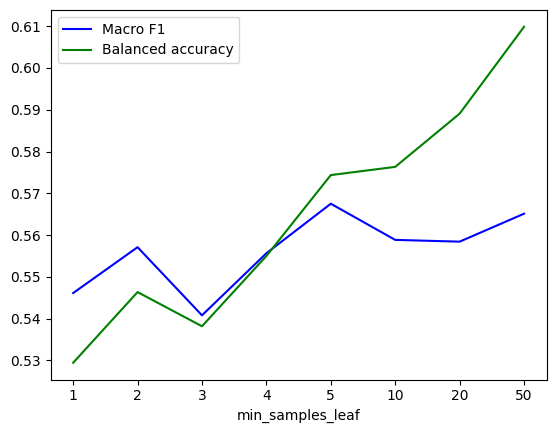

In [58]:
# Sprotno reznaje
import matplotlib.pyplot as plt

min_leaf_grid = [1, 2, 3, 4, 5, 10, 20, 50]
macro_f1s = []      # boljše ime kot error1 in error2
balanced_accs = []

for msl in min_leaf_grid:
    f1_scores = []
    bal_acc_scores = []

    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    smote_rf_model = ImbPipeline([
        ("preprocess", preprocess),
        ("smote", SMOTE(random_state=0)),
        ("rf", RandomForestClassifier(min_samples_leaf=msl, random_state=0)),
    ])

    for i, (train_idx, test_idx) in enumerate(kfold.split(X, y)):
        x_train = X.iloc[train_idx, :]
        y_train = y.iloc[train_idx]
        x_test = X.iloc[test_idx]
        y_test = y.iloc[test_idx]

        smote_rf_model.fit(x_train, y_train)
        y_pred = smote_rf_model.predict(x_test)

        f1_scores.append(f1_score(y_test, y_pred, average="macro"))
        bal_acc_scores.append(balanced_accuracy_score(y_test, y_pred))

    macro_f1s.append(np.mean(f1_scores))
    balanced_accs.append(np.mean(bal_acc_scores))

    print(f"min_samples_leaf={msl}: povp. Macro F1={np.mean(f1_scores):.3f}, povp. Balanced accuracy={np.mean(bal_acc_scores):.3f}")

plt.plot(macro_f1s, c="b", label="Macro F1")
plt.plot(balanced_accs, c="g", label="Balanced accuracy")
plt.xticks(list(range(len(min_leaf_grid))), labels=min_leaf_grid)
plt.xlabel("min_samples_leaf")
plt.legend()
plt.show()


Najboljši primer sprotnega rezanja (min_samples_leaf=50) je izboljšal Macro F1 za približno 0.02, Balanced Accuracy pa za 0.08. Metoda je, torej zmanjšala overfitting, ampak ne za veliko.
Balanced accuracy izgleda, da raste z večanjem min št vzorcev v volišču (min_samples_leaf), Macro F1 pa se nekako po min_samples_leaf=5 izravna.

Kot najboljše min št vzorecv v vozlišču bi torej označil 50 (sicer je pri 5, Macro F1 boljši, ampak za zanemarljivo malo, Balanced accuracy pa je opazno slabši).

ccp_alpha=0: povp. Macro F1=0.546, povp. Balanced accuracy=0.529
ccp_alpha=0.0005: povp. Macro F1=0.562, povp. Balanced accuracy=0.552
ccp_alpha=0.001: povp. Macro F1=0.559, povp. Balanced accuracy=0.564
ccp_alpha=0.002: povp. Macro F1=0.578, povp. Balanced accuracy=0.607
ccp_alpha=0.005: povp. Macro F1=0.556, povp. Balanced accuracy=0.606
ccp_alpha=0.01: povp. Macro F1=0.553, povp. Balanced accuracy=0.613
ccp_alpha=0.02: povp. Macro F1=0.537, povp. Balanced accuracy=0.603
ccp_alpha=0.05: povp. Macro F1=0.462, povp. Balanced accuracy=0.563


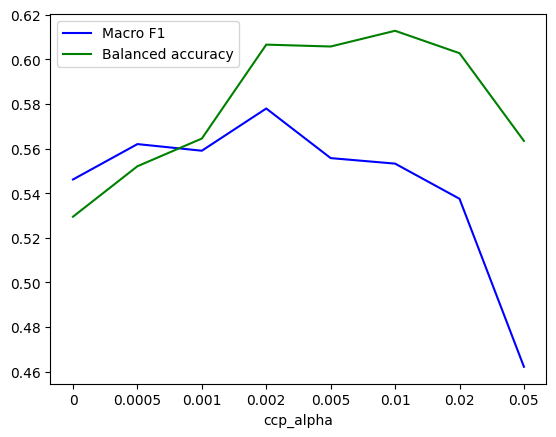

In [59]:
# Naknadno rezanje

ccp_alpha_grid = [0, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05]
macro_f1s = []
balanced_accs = []

for cp in ccp_alpha_grid:
    f1_scores = []
    bal_acc_scores = []

    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    smote_rf_model = ImbPipeline([
        ("preprocess", preprocess),
        ("smote", SMOTE(random_state=0)),
        ("rf", RandomForestClassifier(ccp_alpha=cp, random_state=0)),
    ])

    for i, (train_idx, test_idx) in enumerate(kfold.split(X, y)):
        x_train = X.iloc[train_idx, :]
        y_train = y.iloc[train_idx]
        x_test = X.iloc[test_idx]
        y_test = y.iloc[test_idx]

        smote_rf_model.fit(x_train, y_train)
        y_pred = smote_rf_model.predict(x_test)

        f1_scores.append(f1_score(y_test, y_pred, average="macro"))
        bal_acc_scores.append(balanced_accuracy_score(y_test, y_pred))

    macro_f1s.append(np.mean(f1_scores))
    balanced_accs.append(np.mean(bal_acc_scores))

    print(f"ccp_alpha={cp}: povp. Macro F1={np.mean(f1_scores):.3f}, povp. Balanced accuracy={np.mean(bal_acc_scores):.3f}")

plt.plot(macro_f1s, c="b", label="Macro F1")
plt.plot(balanced_accs, c="g", label="Balanced accuracy")
plt.xticks(list(range(len(ccp_alpha_grid))), labels=ccp_alpha_grid)
plt.xlabel("ccp_alpha")
plt.legend()
plt.show()


Najboljši rezultat naknadnega rezanja (ccp_alpha=0.002) je boljši od sprotnega rezanja, ampak ne bistveno (Macro F1 je za približno 0.01 višji).

S naknadnim rezanjem nam je, torej uspelo zmanjšati overfitting in izboljšati rezultate metrik, ampak za manj kot bi si želeli.

**V nadeljevanju bom uporabljal ccp_alpha=0.002 + SMOTE** in še poskusil najti optimalno število dreves in delež parametrov.

#### Optimalno število dreves

n_estimators=1: povp. Macro F1=0.482, povp. Balanced accuracy=0.535
n_estimators=2: povp. Macro F1=0.495, povp. Balanced accuracy=0.541
n_estimators=5: povp. Macro F1=0.540, povp. Balanced accuracy=0.579
n_estimators=10: povp. Macro F1=0.554, povp. Balanced accuracy=0.583
n_estimators=20: povp. Macro F1=0.548, povp. Balanced accuracy=0.573
n_estimators=50: povp. Macro F1=0.570, povp. Balanced accuracy=0.593
n_estimators=100: povp. Macro F1=0.578, povp. Balanced accuracy=0.607
n_estimators=200: povp. Macro F1=0.579, povp. Balanced accuracy=0.603


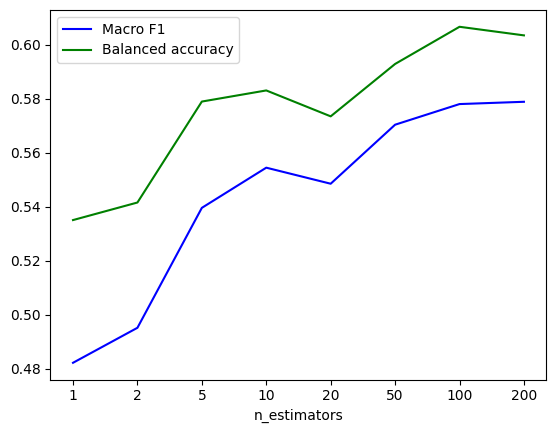

In [60]:
import matplotlib.pyplot as plt

macro_f1s = []
balanced_accs = []

for num_trees in [1, 2, 5, 10, 20, 50, 100, 200]:
    f1_scores = []
    bal_acc_scores = []

    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    smote_rf_model = ImbPipeline([
        ("preprocess", preprocess),
        ("smote", SMOTE(random_state=0)),
        ("rf", RandomForestClassifier(n_estimators=num_trees, ccp_alpha=0.002, random_state=0)),
    ])

    for i, (train_idx, test_idx) in enumerate(kfold.split(X, y)):
        x_train = X.iloc[train_idx, :]
        y_train = y.iloc[train_idx]
        x_test = X.iloc[test_idx]
        y_test = y.iloc[test_idx]

        smote_rf_model.fit(x_train, y_train)
        y_pred = smote_rf_model.predict(x_test)

        f1_scores.append(f1_score(y_test, y_pred, average="macro"))
        bal_acc_scores.append(balanced_accuracy_score(y_test, y_pred))

    macro_f1s.append(np.mean(f1_scores))
    balanced_accs.append(np.mean(bal_acc_scores))

    print(f"n_estimators={num_trees}: povp. Macro F1={np.mean(f1_scores):.3f}, povp. Balanced accuracy={np.mean(bal_acc_scores):.3f}")

plt.plot(macro_f1s, c="b", label="Macro F1")
plt.plot(balanced_accs, c="g", label="Balanced accuracy")
plt.xticks(list(range(8)), labels=[1, 2, 5, 10, 20, 50, 100, 200])
plt.xlabel("n_estimators")
plt.legend()
plt.show()


Med testiranimi vrednostmi za n_estimators je **najboljših 100 dreves**. Pri 200 dreves je model dosegal zanemarlji boljši Macro F1, ampak je zaradi hitrosti učenja 100 dreves
boljša izbira.

#### Optimalen delež parmetrov

max_features=0.02: povp. Macro F1=0.555, povp. Balanced accuracy=0.561
max_features=0.05: povp. Macro F1=0.568, povp. Balanced accuracy=0.586
max_features=sqrt: povp. Macro F1=0.578, povp. Balanced accuracy=0.607
max_features=0.2: povp. Macro F1=0.575, povp. Balanced accuracy=0.613
max_features=0.35: povp. Macro F1=0.568, povp. Balanced accuracy=0.607
max_features=0.5: povp. Macro F1=0.558, povp. Balanced accuracy=0.595
max_features=0.75: povp. Macro F1=0.540, povp. Balanced accuracy=0.575
max_features=1.0: povp. Macro F1=0.527, povp. Balanced accuracy=0.563


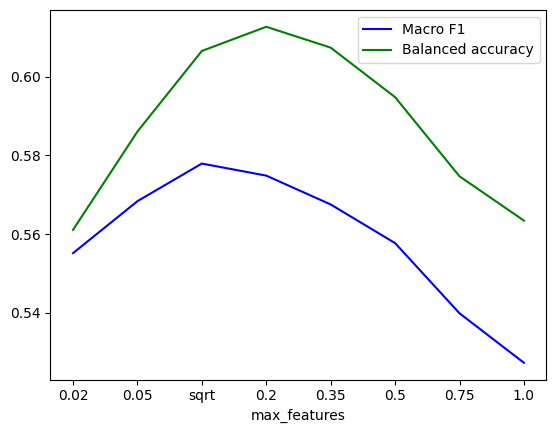

In [61]:
max_features_grid = [0.02, 0.05, "sqrt", 0.2, 0.35, 0.5, 0.75, 1.0]  # deleži značilk. “sqrt“ je privzeta vrednost parametra max_features.
macro_f1s = []
balanced_accs = []

for mf in max_features_grid:
    f1_scores = []
    bal_acc_scores = []

    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    smote_rf_model = ImbPipeline([
        ("preprocess", preprocess),
        ("smote", SMOTE(random_state=0)),
        ("rf", RandomForestClassifier(n_estimators=100, ccp_alpha=0.002, max_features=mf, random_state=0)),
    ])

    for i, (train_idx, test_idx) in enumerate(kfold.split(X, y)):
        x_train = X.iloc[train_idx, :]
        y_train = y.iloc[train_idx]
        x_test = X.iloc[test_idx]
        y_test = y.iloc[test_idx]

        smote_rf_model.fit(x_train, y_train)
        y_pred = smote_rf_model.predict(x_test)

        f1_scores.append(f1_score(y_test, y_pred, average="macro"))
        bal_acc_scores.append(balanced_accuracy_score(y_test, y_pred))

    macro_f1s.append(np.mean(f1_scores))
    balanced_accs.append(np.mean(bal_acc_scores))

    print(f"max_features={mf}: povp. Macro F1={np.mean(f1_scores):.3f}, povp. Balanced accuracy={np.mean(bal_acc_scores):.3f}")

plt.plot(macro_f1s, c="b", label="Macro F1")
plt.plot(balanced_accs, c="g", label="Balanced accuracy")
plt.xticks(list(range(len(max_features_grid))), labels=max_features_grid)
plt.xlabel("max_features")
plt.legend()
plt.show()


Najboljši Macro F1 je pri max_features="sqrt“. "sqrt“ pa je privzeta vrednost za parameter max_features, torej smo že v prejšnjem primeru imeli najboljši parameter max_features.

#### Končni model RF in matrika zmot

              precision    recall  f1-score   support

     Dropout      0.892     0.813     0.851      1406
    Enrolled      0.481     0.603     0.535       375
    Graduate      0.306     0.404     0.349        94

    accuracy                          0.750      1875
   macro avg      0.560     0.607     0.578      1875
weighted avg      0.781     0.750     0.762      1875

Macro F1: 0.578
Balanced accuracy: 0.607


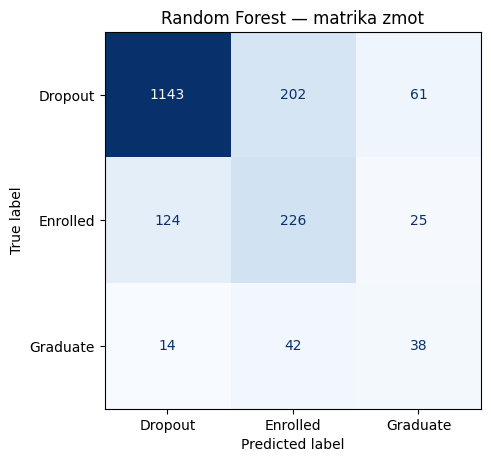

In [62]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict

# Najboljsi RF: ccp_alpha=0.002, ostali parametri privzeti
best_rf_model = ImbPipeline([
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=0)),
    ("rf", RandomForestClassifier(ccp_alpha=0.002, random_state=0)),
])

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
y_pred_cv = cross_val_predict(best_rf_model, X, y, cv=kfold)

print(classification_report(y, y_pred_cv, digits=3))
print(f"Macro F1: {f1_score(y, y_pred_cv, average='macro'):.3f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y, y_pred_cv):.3f}")

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y, y_pred_cv, labels=["Dropout", "Enrolled", "Graduate"], cmap="Blues", ax=ax, colorbar=False
)
ax.set_title("Random Forest — matrika zmot")
plt.tight_layout()
plt.show()

Končni model naključnega gozda:
- RandomForestClassifier(n_estimators=100, max_features="sqrt", ccp_alpha=0.002) 
- SMOTE prevzorčenjem, na značilkah brez identifikatorjev in "sumljivih" stolpcev. 

Edini parameter, ki je prinesel pravo izboljšavo, je ccp_alpha=0.002 (naknadno rezanje):
macro F1 se je z njim dvignil z 0.546 na 0.578, balanced accuracy pa z 0.529 na 0.607. n_estimators in max_features sta ostala na privzetih vrednostih, saj se je pri iskanju izkazalo, da sta ti že optimalni.

Rezultati (5-kratna stratificirana navzkrižna validacija, macro F1 = 0.578, balanced accuracy = 0.607):

Razred Dropout je daleč najbolje napovedan (F1 0.851, precision 0.892, recall 0.813). Pravilno je razvrščenih 1143 od 1406 primerov. To je pričakovano, saj ima s 1406 primeri daleč največ učnih podatkov.
Razred Enrolled je v sredini (F1 = 0.535). Pravilno napovedanih 226 od 375.
Njegova največja skupina napak gre v Dropout, kar je smiselno, saj sta oba izida povezana z nedokončanim študijem.
Razred Graduate ostaja najšibkejši (F1 = 0.349, recall 0.404). Pravilno napovedanih je le 38 od 94 primerov.

**Ključno opažanje iz matrike zmot**:

Model razred Graduate pogostje zamenja z Enrolled (42 primerov, 44.7 %), kot ga pravilno napove (38 primerov, 40.4 %). Prav ta zamenjava je glavni vir izgube Macro F1. Razlago sta:
- Graduate ima z 94 primeri premalo učnih podatkov za zanesljivo ločevanje,
- Graduate in Enrolled sta si tudi vsebinsko blizu, saj oba pomenita, da študent študija ni opustil, in si delita podobne vrednosti ključnih značilk.

**Primerjava z logistično regresijo iz naloge 4.b**:

RF je boljši pri obeh večjih razredih (Dropout 0.851 proti 0.819, Enrolled 0.535 proti 0.524), ampak malo slabši pri Graduate (0.349 proti 0.369). Modela se torej ne razlikujeta le po skupni uspešnosti, ampak tudi po tem, kje delata napake.

Nadaljujmo na novo družino modelov.

### Gradient Boosting
Gradient Boosting sicer nismo uporabljalo na vajah, zato bom ga na kratko predstavil.

Gre za zaporedno grajenje dreves, kje se vsako naslednje uči iz napak prejšnje. To je drugače od naključnega gozda, saj se tam drevesa učijo vzporedno in neodvisno od drug druge.

Uporabil bom `HistGradientBoostingClassifier`. To je histogramska različica gradient boostinga.

Za boljšo primerljivost z naključnim gozdom sem obdržal isto predobdelavo (`preprocess`) in SMOTE kot pri RF.


In [63]:
from sklearn.ensemble import HistGradientBoostingClassifier

# HistGradientBoostingClassifier ne sprejme redkih matrik, ki jih dobimo pri OneHotEncoder,
# zato tu uporabim enako predobdelavo kot pri RF, le z gostim izhodom (nastavimo sparse_output=False)
preprocess_dense = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categorical_cols),
])

smote_hgb_model = ImbPipeline([
    ("preprocess", preprocess_dense),
    ("smote", SMOTE(random_state=0)),
    ("hgb", HistGradientBoostingClassifier(random_state=0)),
])


In [64]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

macro_f1s = []
balanced_accs = []

for i, (train_index, test_index) in enumerate(kfold.split(X, y)):
    x_train = X.iloc[train_index, :]
    y_train = y.iloc[train_index]

    x_test = X.iloc[test_index]
    y_test = y.iloc[test_index]

    smote_hgb_model.fit(x_train, y_train)
    y_pred = smote_hgb_model.predict(x_test)

    f1 = f1_score(y_test, y_pred, average='macro')
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    macro_f1s.append(f1)
    balanced_accs.append(bal_acc)

    print(f"Fold {i}: Macro F1: {f1}, Balanced accuracy: {bal_acc}")

print(f"Povprečen Macro F1: {np.mean(macro_f1s):.3f}, "
      f"povprečen Balanced accuracy: {np.mean(balanced_accs):.3f}")


Fold 0: Macro F1: 0.504747827823829, Balanced accuracy: 0.4802364066193854
Fold 1: Macro F1: 0.46253653156878966, Balanced accuracy: 0.443059249547356
Fold 2: Macro F1: 0.5507249777553376, Balanced accuracy: 0.5305945765957004
Fold 3: Macro F1: 0.49470547744995436, Balanced accuracy: 0.48187300992695264
Fold 4: Macro F1: 0.5997058191500241, Balanced accuracy: 0.5879552974964101
Povprečen Macro F1: 0.522, povprečen Balanced accuracy: 0.505


Rezlutati prvega modela GB niso nič posebnega. Celo so slabši od prvega RF + SMOTE. Podobno kot pri RF se bo treba poigrati s parametri, da se zmanjša overfitting.

#### Optimalna `learning_rate` in `max_iter`

Prej sem omenil, da Boosting gradi drevesa zapored in naslednje popravlja napake prejšnje:
- `max_iter`...koliko takih popravkov naredimo (št. iteracij/dreves),
- `learning_rate`...kako močno upoštevamo vsak popravek. Napoved vsakega drevesa se pred seštevanjm pomnoži s to vrednostjo, torej manjša vrednost pomeni previdnejše korake

Parametra delujeta skupaj: zmnožek določa, koliko se model skupno premakne. Majhna
`learning_rate` zahteva več iteracij (počasno in bolj stabilno učenje), velika pa doseže vrh že
pri malo iteracijah in nato začne overfittati. Zato ju ne moremo iskati ločeno, ampak ju
preverimo v parih.

Pri Boostingu se napake seštevajo in preveč iteracij model pokvari.


learning_rate=0.03, max_iter=50: povp. Macro F1=0.538, povp. Balanced accuracy=0.543
learning_rate=0.03, max_iter=100: povp. Macro F1=0.535, povp. Balanced accuracy=0.521
learning_rate=0.03, max_iter=200: povp. Macro F1=0.532, povp. Balanced accuracy=0.511
learning_rate=0.05, max_iter=50: povp. Macro F1=0.535, povp. Balanced accuracy=0.525
learning_rate=0.05, max_iter=100: povp. Macro F1=0.548, povp. Balanced accuracy=0.527
learning_rate=0.05, max_iter=200: povp. Macro F1=0.536, povp. Balanced accuracy=0.517
learning_rate=0.1, max_iter=50: povp. Macro F1=0.524, povp. Balanced accuracy=0.508
learning_rate=0.1, max_iter=100: povp. Macro F1=0.522, povp. Balanced accuracy=0.505
learning_rate=0.1, max_iter=200: povp. Macro F1=0.521, povp. Balanced accuracy=0.504
learning_rate=0.2, max_iter=50: povp. Macro F1=0.559, povp. Balanced accuracy=0.536
learning_rate=0.2, max_iter=100: povp. Macro F1=0.534, povp. Balanced accuracy=0.513
learning_rate=0.2, max_iter=200: povp. Macro F1=0.540, povp. Ba

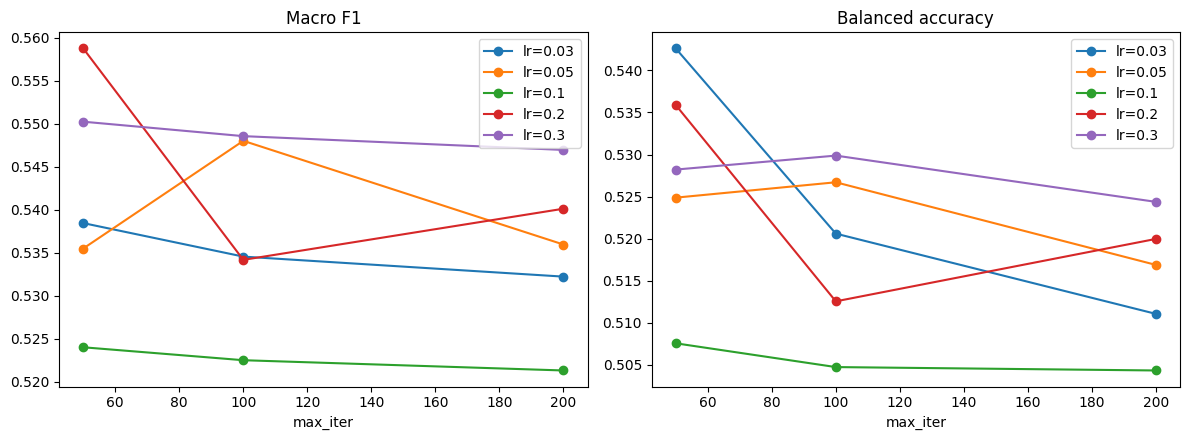

In [65]:
# NASLEDNJA KODA JE BILA NAPISANA S POMOČJO UMETNE INTELIGENCE

lr_grid = [0.03, 0.05, 0.1, 0.2, 0.3]
max_iter_grid = [50, 100, 200]

macro_f1_krivulje = {}
balanced_acc_krivulje = {}

for lr in lr_grid:
    macro_f1s = []
    balanced_accs = []

    for mi in max_iter_grid:
        f1_scores = []
        bal_acc_scores = []

        kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
        smote_hgb_model = ImbPipeline([
            ("preprocess", preprocess_dense),
            ("smote", SMOTE(random_state=0)),
            ("hgb", HistGradientBoostingClassifier(
                learning_rate=lr, max_iter=mi, random_state=0)),
        ])

        for train_idx, test_idx in kfold.split(X, y):
            x_train = X.iloc[train_idx, :]
            y_train = y.iloc[train_idx]
            x_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]

            smote_hgb_model.fit(x_train, y_train)
            y_pred = smote_hgb_model.predict(x_test)

            f1_scores.append(f1_score(y_test, y_pred, average="macro"))
            bal_acc_scores.append(balanced_accuracy_score(y_test, y_pred))

        macro_f1s.append(np.mean(f1_scores))
        balanced_accs.append(np.mean(bal_acc_scores))

        print(f"learning_rate={lr}, max_iter={mi}: "
              f"povp. Macro F1={np.mean(f1_scores):.3f}, "
              f"povp. Balanced accuracy={np.mean(bal_acc_scores):.3f}")

    macro_f1_krivulje[lr] = macro_f1s
    balanced_acc_krivulje[lr] = balanced_accs

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for lr in lr_grid:
    axes[0].plot(max_iter_grid, macro_f1_krivulje[lr], marker="o", label=f"lr={lr}")
    axes[1].plot(max_iter_grid, balanced_acc_krivulje[lr], marker="o", label=f"lr={lr}")

axes[0].set_title("Macro F1")
axes[1].set_title("Balanced accuracy")
for ax in axes:
    ax.set_xlabel("max_iter")
    ax.legend()
plt.tight_layout()
plt.show()


Najboljši Macro F1 je 0.559 (max_iter=50 in lr=0.2),
najboljši Balance accuracy pa je 0.543 (max_iter=50 in lr=0.03).

Obe metriki večinoma padata z `max_iter`, kar je znak overfittanja. Model je najboljši pri
najmanjšem **testiranem** številu iteracij, vsak nadaljnji popravek pa se uči na podlagi šumu. Po izgledu krivulj, je vrh grafov verjetno levo od `max_iter=50`.

`learning_rate` nima jasnega vzorca, krivulje se sekajo in privzeti `lr=0.1` je celo najslabši.
Celoten razpon na grafu je le prib. 0.04, medtem ko je nihanje med foldi pri RF znašalo prib. 0.06.
Razlike med kombinacijami so torej manjše od šuma navzkrižne validacije in izbira optimalne
kombinacije ne bi bila utemeljena.
Kljub temu, bom **v nadeljevanju uporabil lr=0.2**, saj je pri njem model dosegel najvišji Macro F1 in dober Balanced Acc.

V nadaljevanju bom mrežo razširil navzdol (`max_iter` pod 50) in hkrati omejil kompleksnost dreves s parametrom `max_leaf_nodes`.


#### Optimalna `max_leaf_nodes` in `max_iter`

`max_leaf_nodes` omejuje število listov posameznega drevesa, torej kako kompleksen je vsak popravek.

Parametra je treba preveriti skupaj, ker se dopolnjujeta. `max_iter` pove, koliko popravkov
naredimo, `max_leaf_nodes` pa kako močan je vsak. Manjša drevsa so šibkejša, zato jih
potrebujemo več in optimalni `max_iter` se premakne navzgor. Iskanje enega med tem, ko je drugi fiksen bi zgrežilo optimalno kombinacijo.

`max_iter` tokrat testiram pod 50, saj je iz prejšnjega grafa razvidno, da vrh leži levo od
te vrednosti. `learning_rate` pa fiksiram na 0.2.


max_leaf_nodes=3, max_iter=10: povp. Macro F1=0.529 (std 0.012), povp. Balanced accuracy=0.593
max_leaf_nodes=3, max_iter=20: povp. Macro F1=0.547 (std 0.025), povp. Balanced accuracy=0.592
max_leaf_nodes=3, max_iter=30: povp. Macro F1=0.559 (std 0.033), povp. Balanced accuracy=0.588
max_leaf_nodes=3, max_iter=50: povp. Macro F1=0.560 (std 0.036), povp. Balanced accuracy=0.573
max_leaf_nodes=5, max_iter=10: povp. Macro F1=0.559 (std 0.030), povp. Balanced accuracy=0.612
max_leaf_nodes=5, max_iter=20: povp. Macro F1=0.554 (std 0.030), povp. Balanced accuracy=0.577
max_leaf_nodes=5, max_iter=30: povp. Macro F1=0.558 (std 0.029), povp. Balanced accuracy=0.564
max_leaf_nodes=5, max_iter=50: povp. Macro F1=0.565 (std 0.046), povp. Balanced accuracy=0.559
max_leaf_nodes=10, max_iter=10: povp. Macro F1=0.558 (std 0.039), povp. Balanced accuracy=0.584
max_leaf_nodes=10, max_iter=20: povp. Macro F1=0.551 (std 0.038), povp. Balanced accuracy=0.546
max_leaf_nodes=10, max_iter=30: povp. Macro F1=0

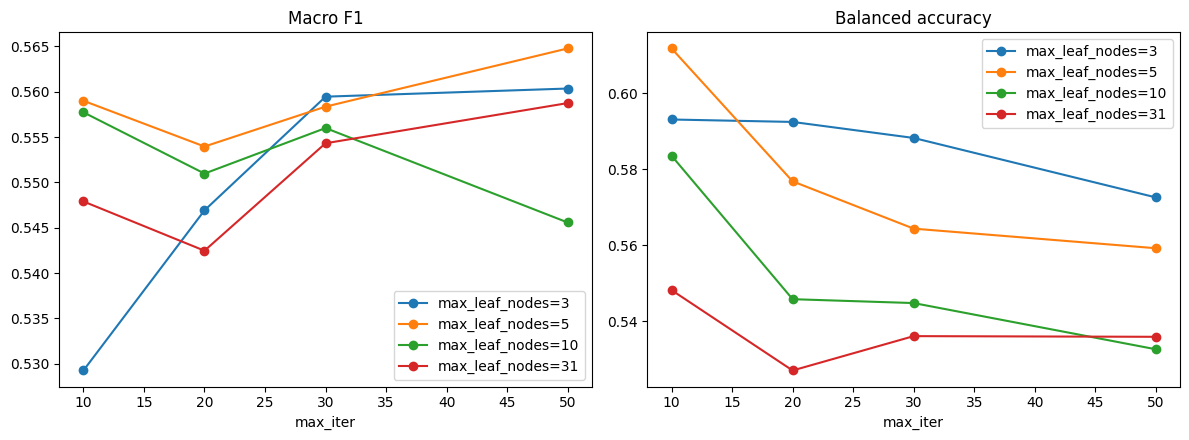

In [66]:
max_iter_grid = [10, 20, 30, 50]
max_leaf_nodes_grid = [3, 5, 10, 31]    # 31 je privzeta vrednost

macro_f1_krivulje = {} 
balanced_acc_krivulje = {}

for mln in max_leaf_nodes_grid:
    macro_f1s = []
    balanced_accs = []

    for mi in max_iter_grid:
        f1_scores = []
        bal_acc_scores = []

        kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
        smote_hgb_model = ImbPipeline([
            ("preprocess", preprocess_dense),
            ("smote", SMOTE(random_state=0)),
            ("hgb", HistGradientBoostingClassifier(
                learning_rate=0.2, max_iter=mi, max_leaf_nodes=mln, random_state=0)),
        ])

        for train_idx, test_idx in kfold.split(X, y):
            x_train = X.iloc[train_idx, :]
            y_train = y.iloc[train_idx]
            x_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]

            smote_hgb_model.fit(x_train, y_train)
            y_pred = smote_hgb_model.predict(x_test)

            f1_scores.append(f1_score(y_test, y_pred, average="macro"))
            bal_acc_scores.append(balanced_accuracy_score(y_test, y_pred))

        macro_f1s.append(np.mean(f1_scores))
        balanced_accs.append(np.mean(bal_acc_scores))

        print(f"max_leaf_nodes={mln}, max_iter={mi}: "
              f"povp. Macro F1={np.mean(f1_scores):.3f} (std {np.std(f1_scores):.3f}), "
              f"povp. Balanced accuracy={np.mean(bal_acc_scores):.3f}")

    macro_f1_krivulje[mln] = macro_f1s
    balanced_acc_krivulje[mln] = balanced_accs

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for mln in max_leaf_nodes_grid:
    axes[0].plot(max_iter_grid, macro_f1_krivulje[mln], marker="o", label=f"max_leaf_nodes={mln}")
    axes[1].plot(max_iter_grid, balanced_acc_krivulje[mln], marker="o", label=f"max_leaf_nodes={mln}")

axes[0].set_title("Macro F1")
axes[1].set_title("Balanced accuracy")
for ax in axes:
    ax.set_xlabel("max_iter")
    ax.legend()
plt.tight_layout()
plt.show()


Omejitev kompleksnosti dreves je pomagala. Majhna drevesa (`max_leaf_nodes` 3 in 5) so pri
obeh metrikah nad velikimi. To pomeni, da je bil prej glavni problem
prevelika kompleksnost posameznega drevesa in ne hitrost učenja.

Metriki pa ne sledita istemu vrzorcu. Balanced accuracy pri vseh velikostih dreves monotono pada z
`max_iter` in je najvišja pri `max_leaf_nodes=5, max_iter=10` (0.612), Macro F1 pa pri majhnih
drevesih z `max_iter` raste in je najvišji pri `max_leaf_nodes=5, max_iter=50` (0.565).
Z večanjem števila iteracij se model torej vse bolj nagiba k večinskim razredom.

Napredek glede na privzete parametre je opazen (Macro F1 z 0.522 na 0.565, balanced accuracy
z 0.505 na 0.612). Po balanced accuracy je GB zdaj primerljiv z RF (0.607), po Macro F1 pa
ostaja slabši (0.578).

Med preverjenimi bi kot najboljšo vrednost `max_iter` izbral 10 in ne 50. Pri `max_iter`=50 je Macro F1 zanemarljivo boljši, Balanced Acc pa za 0.05 višji.

#### Končni model GB in matrika zmot

              precision    recall  f1-score   support

     Dropout      0.889     0.794     0.839      1406
    Enrolled      0.467     0.541     0.501       375
    Graduate      0.255     0.500     0.338        94

    accuracy                          0.729      1875
   macro avg      0.537     0.612     0.560      1875
weighted avg      0.773     0.729     0.747      1875

Macro F1: 0.560
Balanced accuracy: 0.612


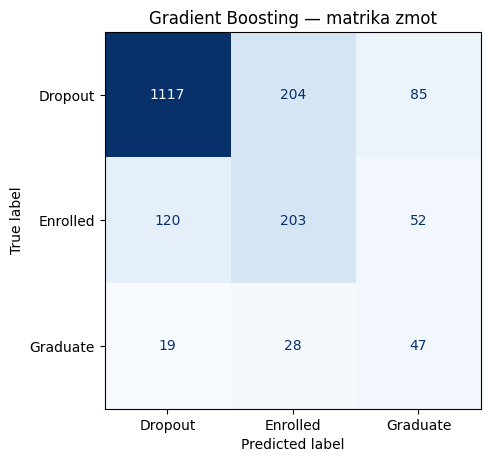

In [67]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict

best_hgb_model = ImbPipeline([
    ("preprocess", preprocess_dense),
    ("smote", SMOTE(random_state=0)),
    ("hgb", HistGradientBoostingClassifier(
        learning_rate=0.2, max_iter=10, max_leaf_nodes=5, random_state=0)),
])

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
y_pred_cv = cross_val_predict(best_hgb_model, X, y, cv=kfold)

print(classification_report(y, y_pred_cv, digits=3))
print(f"Macro F1: {f1_score(y, y_pred_cv, average='macro'):.3f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y, y_pred_cv):.3f}")

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y, y_pred_cv, labels=["Dropout", "Enrolled", "Graduate"], cmap="Blues", ax=ax, colorbar=False
)
ax.set_title("Gradient Boosting — matrika zmot")
plt.tight_layout()
plt.show()


**Končni model gradient boostinga:**

- `HistGradientBoostingClassifier(learning_rate=0.2, max_iter=10, max_leaf_nodes=5)`
- s SMOTE prevzorčenjem, na značilkah brez identifikatorjev in "sumljivih" stolpcev.

**Rezultati (5-kratna stratificirana navzkrižna validacija, Macro F1 = 0.560,
Balanced Accuracy = 0.612):**

Razred Dropout ostaja najbolje napovedan (F1 = 0.839, precision 0.889, recall 0.794),
pravilno razvrščenih 1117 od 1406 primerov. Enrolled je v sredini (F1 = 0.501,
203 od 375), Graduate pa ostaja najšibkejši (F1 = 0.338, 47 od 94).

**Primerjava z naključnim gozdom:**

GB ima višjo Balanced Acc (0.612 proti 0.607), ampak nižji Macro F1 (0.560 proti 0.578). Razlog je
razred Graduate. GB ga pravilno napove 47 krat (recall 0.500), RF pa samo 38 krat (recall 0.404).
Ker Balanced Acc meri le priklic po razredih, GB pri njej izpade bolje.

Posledica je slabša natančnost. GB napove Graduate 184 krat, pravilnih pa je le 47 (precision 0.255),
od tega je 85 primerov v resnici Dropout. F1 razreda Graduate je
zato pri obeh modelih praktično enak (0.338 proti 0.349) in ostaja glavni vir izgube Macro F1.


### Primerjava končnih modelov

Za konec primerjajmo še vse tri družine modelov, vsako z njenimi najboljšimi parametri.


Log. regresija: Macro F1=0.550, Balanced accuracy=0.614
Random Forest: Macro F1=0.578, Balanced accuracy=0.607
Gradient Boosting: Macro F1=0.560, Balanced accuracy=0.612


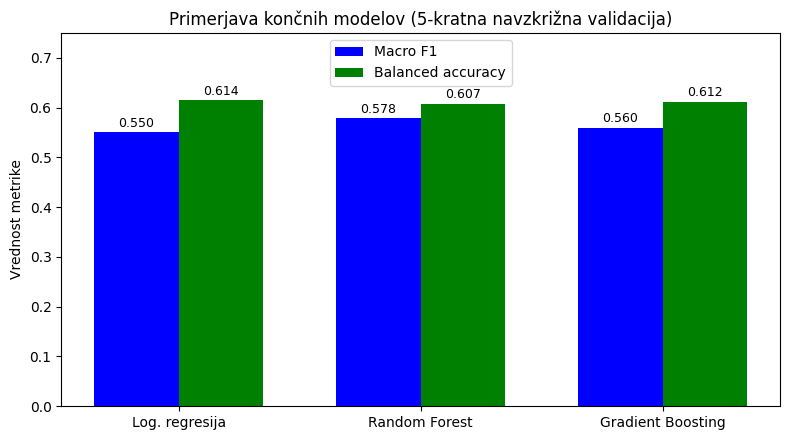

In [68]:
from sklearn.model_selection import cross_val_predict

koncni_modeli = {
    "Log. regresija": ImbPipeline([
        ("preprocess", preprocess),
        ("smote", SMOTE(random_state=0)),
        ("logreg", LogisticRegression(max_iter=2000, random_state=0)),
    ]),
    "Random Forest": ImbPipeline([
        ("preprocess", preprocess),
        ("smote", SMOTE(random_state=0)),
        ("rf", RandomForestClassifier(ccp_alpha=0.002, random_state=0)),
    ]),
    "Gradient Boosting": ImbPipeline([
        ("preprocess", preprocess_dense),
        ("smote", SMOTE(random_state=0)),
        ("hgb", HistGradientBoostingClassifier(
            learning_rate=0.2, max_iter=10, max_leaf_nodes=5, random_state=0)),
    ]),
}

imena = list(koncni_modeli)
macro_f1s = []
balanced_accs = []

for ime, model in koncni_modeli.items():
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    y_pred_cv = cross_val_predict(model, X, y, cv=kfold)

    macro_f1s.append(f1_score(y, y_pred_cv, average="macro"))
    balanced_accs.append(balanced_accuracy_score(y, y_pred_cv))

    print(f"{ime}: Macro F1={macro_f1s[-1]:.3f}, Balanced accuracy={balanced_accs[-1]:.3f}")

x = np.arange(len(imena))
sirina = 0.35

fig, ax = plt.subplots(figsize=(8, 4.5))
stolpci1 = ax.bar(x - sirina/2, macro_f1s, sirina, label="Macro F1", color="b")
stolpci2 = ax.bar(x + sirina/2, balanced_accs, sirina, label="Balanced accuracy", color="g")

ax.bar_label(stolpci1, fmt="%.3f", padding=2, fontsize=9)
ax.bar_label(stolpci2, fmt="%.3f", padding=2, fontsize=9)

ax.set_xticks(x, imena)
ax.set_ylim(0, 0.75)
ax.set_ylabel("Vrednost metrike")
ax.set_title("Primerjava končnih modelov (5-kratna navzkrižna validacija)")
ax.legend()
plt.tight_layout()
plt.show()


Vsi trije modeli so si presenetljivo blizu. Razlike v Macro F1 so v razponu nekaj stotink.

Kot najboljši model razglašam **naključni gozd**, saj ima najvišji Macro F1 (0.578) in hkrati
balanced accuracy (0.607), ki skoraj enaka najboljši doseženi (GB 0.612). 

Ključna ugotovitev naloge pa je, da izbira modela ni bila odločilna. Razliek med modeli so vse znotrja mej šuma, čeprav gre za tri zelo različne pristope in čeprav smo pri zadnjih dveh sistematično iskali optimalne parametre. Omejitev torej ni v modelih, ampak v podatkih:
- razred Graduate ima le 94 primerov, kar je premalo za zanesljivo učenje,
- razreda Graduate in Enrolled sta si vsebinsko blizu in si delita podobne vrednosti značilk,
- velik del značilk v množici dn3_cracked je šum brez napovedne moči, kar je pokazala že analiza z algoritmom ReliefF.

Nadaljnje izboljšave bi bilo zato treba iskati pri podatkih (več primerov manjšinskih razredov,
boljše značilke), ne pri izbiri ali uglaševanju modela.
